# Análisis FBG: 3 Fibras (11 sensores totales) - 04/03/2026

## 🔬 Configuración del Setup

**Fecha de medición:** 04 de marzo de 2026  
**Hora de inicio:** 16:16h

### Fibras analizadas:
- **Canal 0:** DW-3 Ormocer-T → 4 sensores FBG
- **Canal 1:** PEEK-6 → 3 sensores FBG
- **Canal 2:** POLY-1 Poliamida → 4 sensores FBG

**Total:** 11 sensores FBG (4 + 3 + 4)

### Análisis de calidad incluido:
- ✅ Detección de picos FBG
- ✅ FWHM (ancho del pico)
- ✅ Espaciado entre sensores
- ✅ SLSR (Side-Lobe Suppression Ratio)
- ✅ Longitud física del sensor FBG
- ✅ Tabla comparativa entre fibras
- ...

## 1️⃣ Importar Librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy import stats
from scipy.signal import find_peaks, peak_widths
import uproot
import pandas as pd

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2️⃣ Cargar Datos del Archivo ROOT

In [2]:
# 🔧 CONFIGURACIÓN
filepath = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260304.root"
TIME_SHIFT = datetime.timedelta(hours=2)  # Ajustar según sea necesario

print(f"📂 Cargando archivo: {filepath}")
print(f"⏱️  TIME_SHIFT: {TIME_SHIFT.total_seconds()/3600:.1f} horas")

# Cargar archivo ROOT
file = uproot.open(filepath)
print(f"✅ Archivo abierto")
print(f"   Keys: {file.keys()}")

# Función para obtener el ciclo más reciente
def latest_key(f, name):
    candidates = [k for k in f.keys() if k.split(";")[0] == name]
    if not candidates:
        return None
    return sorted(candidates, key=lambda k: int(k.split(";")[1]))[-1]

# Cargar TTrees
key_peak = latest_key(file, "peak")
key_spectrum = latest_key(file, "spectrum")

tree_peak = file[key_peak]
data_peak = tree_peak.arrays(library="np")
print(f"✅ TTree '{key_peak}': {tree_peak.num_entries} entradas")

if key_spectrum:
    tree_spectrum = file[key_spectrum]
    data_spectrum = tree_spectrum.arrays(library="np")
    print(f"✅ TTree '{key_spectrum}': {tree_spectrum.num_entries} entradas")
    print(f"   Spectrum shape: {data_spectrum['wav'].shape}")
else:
    data_spectrum = None
    print("⚠️  No spectrum data available")

📂 Cargando archivo: /eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260304.root
⏱️  TIME_SHIFT: 2.0 horas
✅ Archivo abierto
   Keys: ['peak;2', 'spectrum;2']
✅ TTree 'peak;2': 29375 entradas
✅ TTree 'spectrum;2': 117 entradas
   Spectrum shape: (117, 2, 3, 39200)


## 3️⃣ Configuración de Sensores FBG

Define la configuración de los 11 sensores en las 3 fibras.

In [3]:
# Configuración de sensores FBG por canal/fibra
fbg_config = [
    # Canal 0: DW-3 (4 sensores)
    {"label": "DW3-FBG1-P",   "sensor": 0, "pol": 0, "fiber": "DW-3",   "channel": 0},
    {"label": "DW3-FBG1-S",   "sensor": 0, "pol": 1, "fiber": "DW-3",   "channel": 0},
    {"label": "DW3-FBG2-P",   "sensor": 1, "pol": 0, "fiber": "DW-3",   "channel": 0},
    {"label": "DW3-FBG2-S",   "sensor": 1, "pol": 1, "fiber": "DW-3",   "channel": 0},
    {"label": "DW3-FBG3-P",   "sensor": 2, "pol": 0, "fiber": "DW-3",   "channel": 0},
    {"label": "DW3-FBG3-S",   "sensor": 2, "pol": 1, "fiber": "DW-3",   "channel": 0},
    {"label": "DW3-FBG4-P",   "sensor": 3, "pol": 0, "fiber": "DW-3",   "channel": 0},
    {"label": "DW3-FBG4-S",   "sensor": 3, "pol": 1, "fiber": "DW-3",   "channel": 0},
    
    # Canal 1: PEEK-6 (3 sensores)
    {"label": "PEEK6-FBG1-P", "sensor": 0, "pol": 0, "fiber": "PEEK-6", "channel": 1},
    {"label": "PEEK6-FBG1-S", "sensor": 0, "pol": 1, "fiber": "PEEK-6", "channel": 1},
    {"label": "PEEK6-FBG2-P", "sensor": 1, "pol": 0, "fiber": "PEEK-6", "channel": 1},
    {"label": "PEEK6-FBG2-S", "sensor": 1, "pol": 1, "fiber": "PEEK-6", "channel": 1},
    {"label": "PEEK6-FBG3-P", "sensor": 2, "pol": 0, "fiber": "PEEK-6", "channel": 1},
    {"label": "PEEK6-FBG3-S", "sensor": 2, "pol": 1, "fiber": "PEEK-6", "channel": 1},
    
    # Canal 2: POLY-1 (4 sensores)
    {"label": "POLY1-FBG1-P", "sensor": 0, "pol": 0, "fiber": "POLY-1", "channel": 2},
    {"label": "POLY1-FBG1-S", "sensor": 0, "pol": 1, "fiber": "POLY-1", "channel": 2},
    {"label": "POLY1-FBG2-P", "sensor": 1, "pol": 0, "fiber": "POLY-1", "channel": 2},
    {"label": "POLY1-FBG2-S", "sensor": 1, "pol": 1, "fiber": "POLY-1", "channel": 2},
    {"label": "POLY1-FBG3-P", "sensor": 2, "pol": 0, "fiber": "POLY-1", "channel": 2},
    {"label": "POLY1-FBG3-S", "sensor": 2, "pol": 1, "fiber": "POLY-1", "channel": 2},
    {"label": "POLY1-FBG4-P", "sensor": 3, "pol": 0, "fiber": "POLY-1", "channel": 2},
    {"label": "POLY1-FBG4-S", "sensor": 3, "pol": 1, "fiber": "POLY-1", "channel": 2},
]

print(f"✅ Configuración de {len(fbg_config)} canales (11 sensores × 2 polarizaciones)")
print(f"   • DW-3 (canal 0): 4 sensores")
print(f"   • PEEK-6 (canal 1): 3 sensores")
print(f"   • POLY-1 (canal 2): 4 sensores")

✅ Configuración de 22 canales (11 sensores × 2 polarizaciones)
   • DW-3 (canal 0): 4 sensores
   • PEEK-6 (canal 1): 3 sensores
   • POLY-1 (canal 2): 4 sensores


## 4️⃣ Filtrar Rango Temporal (13:50h en adelante)

In [4]:
# Filtrar datos a partir de las 13:50h
t_inicio_seconds = 13 * 3600 + 50 * 60  # 13:50 en segundos desde medianoche

# Extraer timestamps de wavelength
wav_raw = data_peak['wav']
time_wavelength_raw = data_peak['t']

# Verificar estructura de datos
print(f"📊 Estructura de datos:")
print(f"   wav_raw.shape: {wav_raw.shape}")
print(f"   time_wavelength_raw.shape: {time_wavelength_raw.shape if hasattr(time_wavelength_raw, 'shape') else len(time_wavelength_raw)}")

# Convertir a datetime con TIME_SHIFT
fecha = datetime.date(2026, 3, 4)
t_first = datetime.datetime.combine(fecha, datetime.datetime.fromtimestamp(0).time())

# Si time_wavelength_raw es escalar por entrada, usarlo directamente
if hasattr(time_wavelength_raw, 'shape') and len(time_wavelength_raw.shape) > 1:
    # Es multidimensional, tomar primera dimensión
    time_wavelength_flat = time_wavelength_raw.flatten()[:wav_raw.shape[0]]
else:
    time_wavelength_flat = np.atleast_1d(time_wavelength_raw)

# Asegurar que coinciden las dimensiones
n_entries = min(len(time_wavelength_flat), wav_raw.shape[0])
time_wavelength_flat = time_wavelength_flat[:n_entries]
wav_raw = wav_raw[:n_entries]

times_wav_dt = np.array([t_first + datetime.timedelta(seconds=float(t)) + TIME_SHIFT 
                         for t in time_wavelength_flat])

# Máscara de tiempo >= 13:50
mask_time = np.array([t.hour * 3600 + t.minute * 60 + t.second >= t_inicio_seconds 
                      for t in times_wav_dt])

# Aplicar filtro
wav_filtered = wav_raw[mask_time]
times_filtered = times_wav_dt[mask_time]

print(f"✅ Rango temporal filtrado")
print(f"   Total puntos: {len(wav_raw)} → {len(wav_filtered)} (desde 13:50h)")
print(f"   Primer punto: {times_filtered[0]}")
print(f"   Último punto: {times_filtered[-1]}")
print(f"   Shape wav_filtered: {wav_filtered.shape}")

📊 Estructura de datos:
   wav_raw.shape: (29375, 2, 11)
   time_wavelength_raw.shape: (29375, 2)
✅ Rango temporal filtrado
   Total puntos: 29375 → 29375 (desde 13:50h)
   Primer punto: 2082-05-05 17:17:49.769156
   Último punto: 2082-05-05 17:19:47.265310
   Shape wav_filtered: (29375, 2, 11)


### 4.1 Visualización de Wavelengths (Picos Detectados)

Plotea todos los picos detectados almacenados en el tree 'peak' para ver:
- El ancho de línea entre sensores
- La calidad del fit en cada sensor
- La evolución temporal de cada FBG

📊 Visualización de Picos Detectados (con filtrado de outliers)
   Shape wav_filtered: (29375, 2, 11)


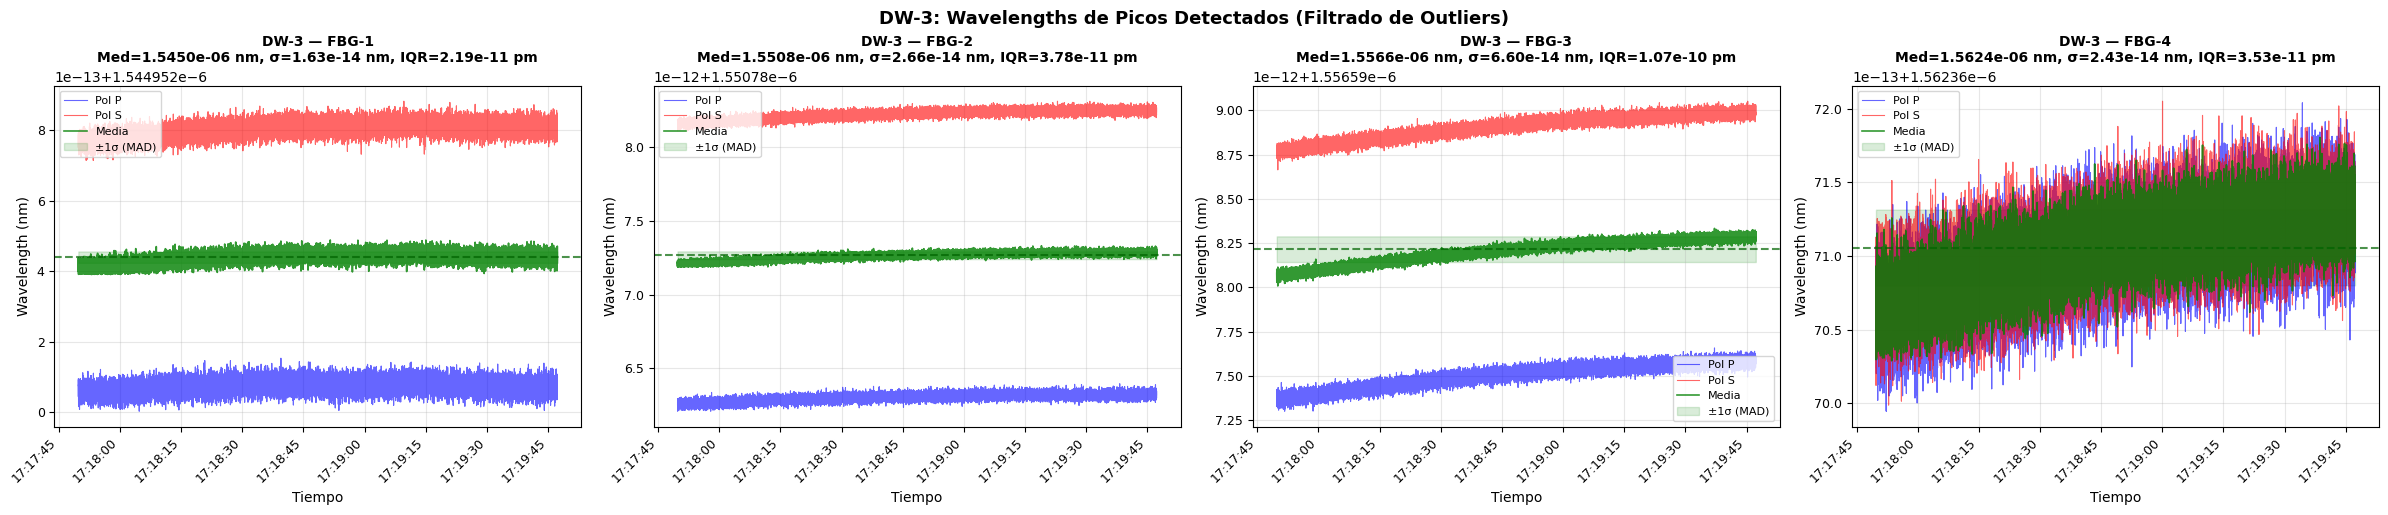

✅ DW-3: 4 sensores plotados
   📏 Anchura promedio (spread): σ=3.330e-11 pm, IQR=5.044e-11 pm
   🔴 Outliers eliminados: 234 puntos totales


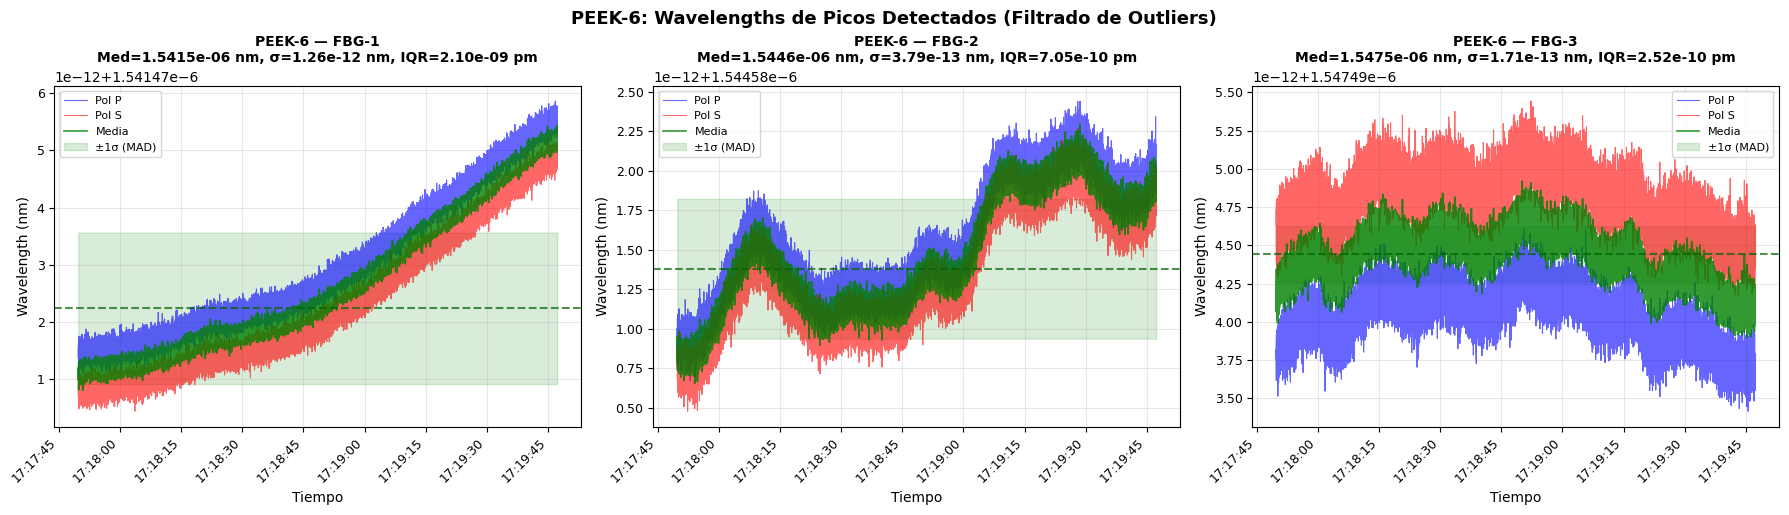

✅ PEEK-6: 3 sensores plotados
   📏 Anchura promedio (spread): σ=6.027e-10 pm, IQR=1.019e-09 pm
   🔴 Outliers eliminados: 4 puntos totales


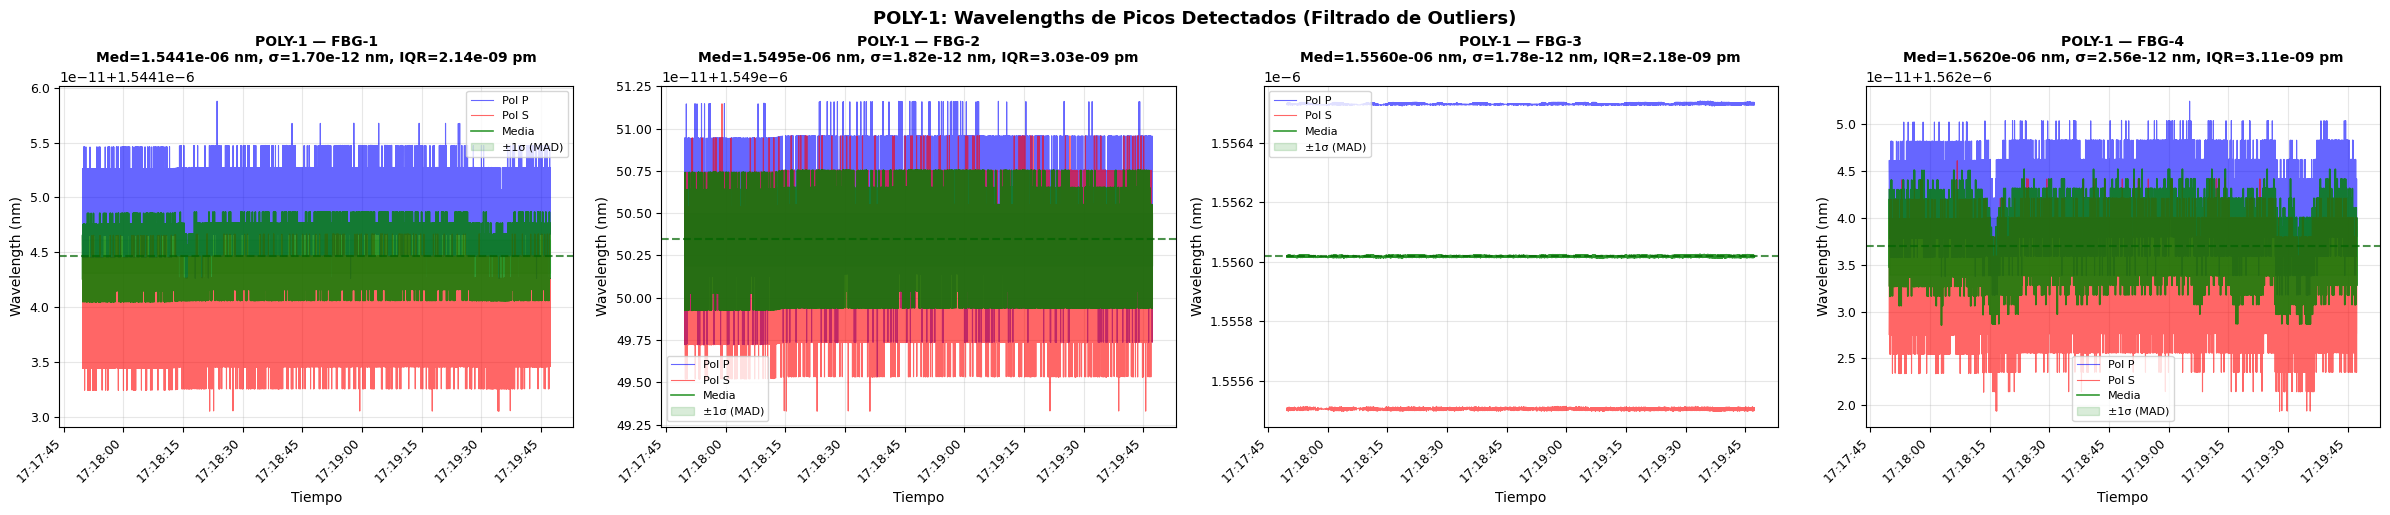

✅ POLY-1: 4 sensores plotados
   📏 Anchura promedio (spread): σ=1.963e-09 pm, IQR=2.616e-09 pm
   🔴 Outliers eliminados: 12734 puntos totales

✅ Ploteo completado:
   • 29375 puntos temporales
   • 2 polarizaciones
   • 11 sensores totales

📊 RESUMEN DE ANCHURA (SPREAD) POR FIBRA:
Fibra      σ promedio (pm)    IQR promedio (pm)    Outliers    
DW-3       3.330e-11          5.044e-11            234         
PEEK-6     6.027e-10          1.019e-09            4           
POLY-1     1.963e-09          2.616e-09            12734       

💡 Interpretación:
   • σ (desviación estándar): dispersión típica de las medidas
   • IQR (rango intercuartílico): anchura del 50% central de los datos
   • Valores más bajos → mejor estabilidad del sensor
   • Outliers: puntos a >3σ (MAD) de la mediana


In [5]:
# Visualizar todos los picos detectados del tree 'peak'
# Estructura: wav_filtered = [n_entries, n_pol, n_sensors]
# Plot: 3 figuras separadas (una por fibra), cada subplot muestra P + S + Media para un sensor
# Incluye filtrado de outliers y medida de 'anchura' (spread) de wavelength

print(f"📊 Visualización de Picos Detectados (con filtrado de outliers)")
print(f"   Shape wav_filtered: {wav_filtered.shape}")

# Función para filtrar outliers usando método robusto (Mediana + MAD)
def filter_outliers_robust(data, sigma_threshold=3.0):
    """
    Filtra outliers usando método robusto: mediana y MAD (Median Absolute Deviation)
    Más resistente a outliers que mean + std
    """
    median = np.median(data)
    mad = np.median(np.abs(data - median))
    # MAD a desviación estándar: σ ≈ 1.4826 × MAD
    mad_std = 1.4826 * mad
    threshold_min = median - sigma_threshold * mad_std
    threshold_max = median + sigma_threshold * mad_std
    mask = (data >= threshold_min) & (data <= threshold_max)
    return mask

# Verificar estructura de datos
if len(wav_filtered.shape) == 3:
    n_entries_filt, n_pol_peak, n_sensors_peak = wav_filtered.shape
    
    # Nombres de fibras y configuración
    fiber_config = {
        'DW-3': {'sensors': 4, 'color': 'tab:blue'},
        'PEEK-6': {'sensors': 3, 'color': 'tab:orange'},
        'POLY-1': {'sensors': 4, 'color': 'tab:red'}
    }
    
    fiber_names = list(fiber_config.keys())
    
    # Almacenar métricas de anchura por fibra
    fiber_spread_metrics = {}
    
    # Crear 3 figuras separadas (una por fibra)
    for fiber_idx, fiber_name in enumerate(fiber_names):
        n_sensors_fiber = fiber_config[fiber_name]['sensors']
        color_fiber = fiber_config[fiber_name]['color']
        
        # Determinar el índice inicial del sensor para esta fibra
        sensor_start = sum([fiber_config[f]['sensors'] for f in fiber_names[:fiber_idx]])
        
        # Crear subplots: 1 fila × n_sensors columnas
        fig, axes = plt.subplots(1, n_sensors_fiber, figsize=(6*n_sensors_fiber, 5))
        
        if n_sensors_fiber == 1:
            axes = [axes]
        
        # Métricas de anchura para esta fibra
        fiber_spreads = []
        
        # Plotear cada sensor en su propio subplot
        for sensor_local in range(n_sensors_fiber):
            sensor_global = sensor_start + sensor_local
            
            if sensor_global >= n_sensors_peak:
                continue
            
            ax = axes[sensor_local]
            
            # Extraer datos de wavelength para Pol P y Pol S
            wav_p = wav_filtered[:, 0, sensor_global]  # Pol P
            wav_s = wav_filtered[:, 1, sensor_global]  # Pol S
            wav_mean = (wav_p + wav_s) / 2.0           # Media P+S
            
            # Filtrar outliers en la media (método robusto)
            mask_clean = filter_outliers_robust(wav_mean, sigma_threshold=3.0)
            times_clean = times_filtered[mask_clean]
            wav_p_clean = wav_p[mask_clean]
            wav_s_clean = wav_s[mask_clean]
            wav_mean_clean = wav_mean[mask_clean]
            
            n_outliers = np.sum(~mask_clean)
            
            # Calcular estadísticas (sin outliers)
            mean_avg = np.median(wav_mean_clean)  # Usar mediana (más robusto)
            std_avg = np.std(wav_mean_clean)
            mad_avg = np.median(np.abs(wav_mean_clean - mean_avg)) * 1.4826  # MAD-std
            
            # Rango intercuartílico (IQR) - métrica robusta de anchura
            q25 = np.percentile(wav_mean_clean, 25)
            q75 = np.percentile(wav_mean_clean, 75)
            iqr = q75 - q25
            
            fiber_spreads.append({
                'sensor': sensor_local + 1,
                'std': std_avg,
                'iqr': iqr,
                'mad': mad_avg,
                'n_outliers': n_outliers
            })
            
            # Plotear P, S y Media (datos limpios)
            ax.plot(times_clean, wav_p_clean, 'b-', linewidth=0.8, alpha=0.6, label='Pol P')
            ax.plot(times_clean, wav_s_clean, 'r-', linewidth=0.8, alpha=0.6, label='Pol S')
            ax.plot(times_clean, wav_mean_clean, 'g-', linewidth=1.2, alpha=0.8, label='Media')
            
            # Línea de mediana
            ax.axhline(mean_avg, color='darkgreen', linestyle='--', linewidth=1.5, alpha=0.7)
            
            # Banda ±1σ (MAD-std)
            ax.fill_between(times_clean, mean_avg - mad_avg, mean_avg + mad_avg,
                           color='green', alpha=0.15, label='±1σ (MAD)')
            
            # Configurar ejes
            ax.set_title(f'{fiber_name} — FBG-{sensor_local+1}\n'
                        f'Med={mean_avg:.4e} nm, σ={std_avg:.2e} nm, IQR={iqr*1e3:.2e} pm',
                        fontsize=10, fontweight='bold')
            ax.set_xlabel('Tiempo', fontsize=10)
            ax.set_ylabel('Wavelength (nm)', fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8, loc='best')
            ax.tick_params(labelsize=9)
            
            # Rotar etiquetas de tiempo
            for tick_label in ax.get_xticklabels():
                tick_label.set_rotation(45)
                tick_label.set_ha('right')
        
        plt.tight_layout()
        plt.suptitle(f'{fiber_name}: Wavelengths de Picos Detectados (Filtrado de Outliers)', 
                     fontsize=13, y=1.02, fontweight='bold')
        plt.show()
        
        # Guardar métricas de anchura
        fiber_spread_metrics[fiber_name] = fiber_spreads
        
        # Calcular promedio de anchura para esta fibra
        avg_std = np.mean([s['std'] for s in fiber_spreads])
        avg_iqr = np.mean([s['iqr'] for s in fiber_spreads])
        total_outliers = sum([s['n_outliers'] for s in fiber_spreads])
        
        print(f"✅ {fiber_name}: {n_sensors_fiber} sensores plotados")
        print(f"   📏 Anchura promedio (spread): σ={avg_std*1e3:.3e} pm, IQR={avg_iqr*1e3:.3e} pm")
        print(f"   🔴 Outliers eliminados: {total_outliers} puntos totales")
    
    print(f"\n✅ Ploteo completado:")
    print(f"   • {n_entries_filt} puntos temporales")
    print(f"   • {n_pol_peak} polarizaciones")
    print(f"   • {n_sensors_peak} sensores totales")
    
    # Tabla resumen de anchura (spread) por fibra
    print(f"\n📊 RESUMEN DE ANCHURA (SPREAD) POR FIBRA:")
    print(f"{'Fibra':<10} {'σ promedio (pm)':<18} {'IQR promedio (pm)':<20} {'Outliers':<12}")
    print("="*65)
    for fiber_name in fiber_names:
        if fiber_name in fiber_spread_metrics:
            spreads = fiber_spread_metrics[fiber_name]
            avg_std = np.mean([s['std'] for s in spreads]) * 1e3  # pm
            avg_iqr = np.mean([s['iqr'] for s in spreads]) * 1e3  # pm
            total_out = sum([s['n_outliers'] for s in spreads])
            print(f"{fiber_name:<10} {avg_std:<18.3e} {avg_iqr:<20.3e} {total_out:<12d}")
    
    print(f"\n💡 Interpretación:")
    print(f"   • σ (desviación estándar): dispersión típica de las medidas")
    print(f"   • IQR (rango intercuartílico): anchura del 50% central de los datos")
    print(f"   • Valores más bajos → mejor estabilidad del sensor")
    print(f"   • Outliers: puntos a >3σ (MAD) de la mediana")
    
else:
    print(f"⚠️  Estructura inesperada. Shape: {wav_filtered.shape}")
    print("   Esperado: (n_entries, n_pol, n_sensors)")    

## 5️⃣ Análisis de Espectros: FWHM y Calidad de Picos

Analiza los espectros de las 3 fibras para determinar:
- FWHM de cada sensor
- Separación entre sensores
- Calidad de los picos

In [6]:
if data_spectrum is None:
    print("⚠️  No hay datos de espectros disponibles")
else:
    spectrum_wav = data_spectrum['wav']
    spectrum_t = data_spectrum['t']
    
    print(f"📊 Análisis de espectros")
    print(f"   Shape: {spectrum_wav.shape}")
    
    # Usar un espectro representativo (último o el del medio)
    idx_espectro = min(50, spectrum_wav.shape[0] - 1)
    n_espectros, n_pol, n_chan, n_puntos = spectrum_wav.shape
    
    print(f"   Espectro #{idx_espectro} seleccionado")
    print(f"   Canales disponibles: {n_chan}")
    print(f"   Polarizaciones: {n_pol}")
    print(f"   Puntos por espectro: {n_puntos}")

📊 Análisis de espectros
   Shape: (117, 2, 3, 39200)
   Espectro #50 seleccionado
   Canales disponibles: 3
   Polarizaciones: 2
   Puntos por espectro: 39200


### 5.1 Plot Espectros Completos (3 canales)

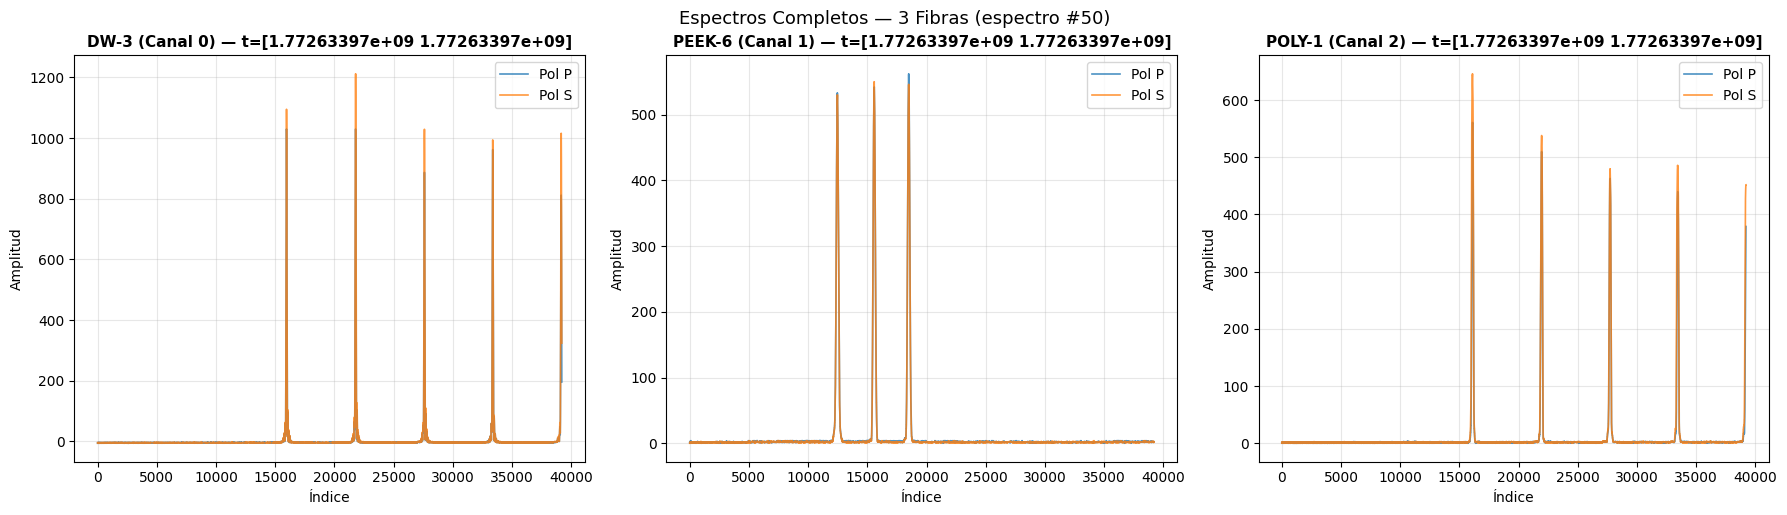

✅ Espectros plotados para 3 canales


In [7]:
if data_spectrum is not None:
    # Configuración de canales
    channel_names = {0: 'DW-3', 1: 'PEEK-6', 2: 'POLY-1'}
    pol_labels = ['Pol P', 'Pol S']
    
    n_channels_available = min(n_chan, 3)
    fig, axes = plt.subplots(1, n_channels_available, figsize=(6*n_channels_available, 5))
    
    if n_channels_available == 1:
        axes = [axes]
    
    for i in range(n_channels_available):
        ax = axes[i]
        for idx_pol in range(n_pol):
            signal = spectrum_wav[idx_espectro, idx_pol, i, :]
            ax.plot(signal, label=pol_labels[idx_pol], linewidth=1.2, alpha=0.8)
        
        t = spectrum_t[idx_espectro]
        fiber_name = channel_names.get(i, f'Canal-{i}')
        ax.set_title(f'{fiber_name} (Canal {i}) — t={t}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Índice', fontsize=10)
        ax.set_ylabel('Amplitud', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.legend()
    
    plt.tight_layout()
    plt.suptitle(f'Espectros Completos — 3 Fibras (espectro #{idx_espectro})', 
                 fontsize=13, y=1.02)
    plt.show()
    print(f"✅ Espectros plotados para {n_channels_available} canales")

### 5.2 Análisis Detallado de Picos FBG

Detecta automáticamente todos los picos FBG en cada canal y calcula:
- Posición del pico
- FWHM (Full Width at Half Maximum)
- Amplitud
- Separación entre sensores consecutivos

In [8]:
# Función para detectar picos FBG
def find_all_fbg_peaks(signal, min_prominence_factor=0.10, min_distance=50, min_height_factor=0.05):
    """
    Detecta todos los picos FBG en una señal de espectro.
    Retorna lista de tuplas: (peak_idx, fwhm, amplitude, left_ip, right_ip)
    """
    sig_max = np.max(signal)
    height = sig_max * min_height_factor
    prominence = sig_max * min_prominence_factor
    
    peaks, properties = find_peaks(signal, prominence=prominence, 
                                   distance=min_distance, height=height)
    
    if len(peaks) == 0:
        return []
    
    results = []
    widths, w_heights, left_ips, right_ips = peak_widths(signal, peaks, rel_height=0.5)
    
    for i, peak_idx in enumerate(peaks):
        results.append({
            'peak_idx': peak_idx,
            'fwhm': widths[i],
            'amplitude': signal[peak_idx],
            'left_ip': left_ips[i],
            'right_ip': right_ips[i],
            'width_height': w_heights[i]
        })
    
    return results

# Analizar cada canal
if data_spectrum is not None:
    fbg_analysis_results = {}
    
    for ch in range(n_channels_available):
        fiber_name = channel_names.get(ch, f'Canal-{ch}')
        print(f"\n{'='*80}")
        print(f"📊 Análisis de {fiber_name} (Canal {ch})")
        print(f"{'='*80}")
        
        fbg_analysis_results[fiber_name] = {}
        
        for pol_idx in range(n_pol):
            pol_name = pol_labels[pol_idx]
            signal = spectrum_wav[idx_espectro, pol_idx, ch, :]
            peaks = find_all_fbg_peaks(signal)
            
            fbg_analysis_results[fiber_name][pol_name] = peaks
            
            print(f"\n  {pol_name}: {len(peaks)} picos FBG detectados")
            for i, peak in enumerate(peaks, 1):
                print(f"    FBG-{i}: idx={peak['peak_idx']:5d}, "
                      f"FWHM={peak['fwhm']:6.2f} pts, "
                      f"Amp={peak['amplitude']:8.2f}")
            
            # Calcular espaciado entre sensores
            if len(peaks) > 1:
                print(f"\n  Espaciado entre sensores ({pol_name}):")
                for i in range(len(peaks) - 1):
                    spacing = peaks[i+1]['peak_idx'] - peaks[i]['peak_idx']
                    print(f"    FBG-{i+1} → FBG-{i+2}: {spacing} pts")
    
    print(f"\n{'='*80}")
    print("✅ Análisis de picos FBG completado para las 3 fibras")


📊 Análisis de DW-3 (Canal 0)

  Pol P: 5 picos FBG detectados
    FBG-1: idx=15952, FWHM= 76.91 pts, Amp= 1030.00
    FBG-2: idx=21786, FWHM= 78.43 pts, Amp= 1030.00
    FBG-3: idx=27598, FWHM= 77.33 pts, Amp=  887.00
    FBG-4: idx=33367, FWHM= 80.40 pts, Amp=  962.00
    FBG-5: idx=39146, FWHM= 66.38 pts, Amp=  812.00

  Espaciado entre sensores (Pol P):
    FBG-1 → FBG-2: 5834 pts
    FBG-2 → FBG-3: 5812 pts
    FBG-3 → FBG-4: 5769 pts
    FBG-4 → FBG-5: 5779 pts

  Pol S: 5 picos FBG detectados
    FBG-1: idx=15952, FWHM= 77.58 pts, Amp= 1095.00
    FBG-2: idx=21788, FWHM= 80.21 pts, Amp= 1212.00
    FBG-3: idx=27599, FWHM= 78.67 pts, Amp= 1029.00
    FBG-4: idx=33367, FWHM= 80.54 pts, Amp=  994.00
    FBG-5: idx=39150, FWHM= 64.39 pts, Amp= 1016.00

  Espaciado entre sensores (Pol S):
    FBG-1 → FBG-2: 5836 pts
    FBG-2 → FBG-3: 5811 pts
    FBG-3 → FBG-4: 5768 pts
    FBG-4 → FBG-5: 5783 pts

📊 Análisis de PEEK-6 (Canal 1)

  Pol P: 3 picos FBG detectados
    FBG-1: idx=12470,

## 6️⃣ Análisis de Calidad v2: Métricas con Sentido Físico

### 📡 Interrogador FAZT I4G-16 — Especificaciones Relevantes

| Parámetro | Valor |
|-----------|-------|
| Rango λ | 1529.0 – 1568.2 nm (39.2 nm) |
| Resolución | 1 pm (= 1 punto del espectro) |
| P láser / canal | +0 a +3 dBm (típico ~2 dBm) |
| Rango dinámico | > 30 dB óptico |
| Ganancia receptor | 4 niveles, 12 dB total |
| FWHM soportado | 40 pm – 1.5 nm |
| Repetibilidad | < 0.05 pm (σ, 10s, FWHM=100pm, P_peak=−15dBm) |
| Polarizaciones | 2 (P y S), conmutadas por barrido |

### 🔬 Métricas Calculadas

**SNR (Signal-to-Noise Ratio):**
$$\text{SNR (dB)} = 10 \cdot \log_{10}\left(\frac{\text{Amplitud pico}}{\text{Baseline local}}\right)$$
- Mide cuánto sobresale el pico del ruido. **NO es reflectividad absoluta** (necesitaríamos potencia incidente calibrada).

**SLSR (Side-Lobe Suppression Ratio) — adaptativo al FWHM:**
$$\text{SLSR (dB)} = 10 \cdot \log_{10}\left(\frac{\text{Pico principal}}{\text{Max lóbulo lateral}}\right)$$
- **Inner guard = 1.5 × FWHM** (excluye la cola del pico principal)
- **Outer guard = min(spacing/2, 4.0 nm)** (no alcanza al pico vecino)
- FBG uniforme teórico: SLSR ≈ 13.3 dB (primer lóbulo de sinc²)

**Ancho de banda multi-nivel:**
- **BW@3dB = FWHM** (pm): ancho a mitad de potencia
- **BW@20dB** (pm): ancho al 1% del pico
- **Shape Factor = BW@20dB / BW@3dB**: forma del pico (Gaussiana ≈ 3.0, sinc² ≈ 4.7, flat-top → 1.0)

**SAR (Shape Asymmetry Ratio):**
$$\text{SAR (\%)} = \frac{|W_{\text{izq}} - W_{\text{der}}|}{W_{\text{izq}} + W_{\text{der}}} \times 100$$
a nivel FWHM. SAR = 0% → pico perfectamente simétrico.

**Cross-polarización:**
- **Birrefringencia** = |λ\_P − λ\_S| en pm
- **PDL** = 10·log₁₀(max(Amp\_P, Amp\_S) / min(Amp\_P, Amp\_S)) en dB

In [9]:
if data_spectrum is not None:
    # ══════════════════════════════════════════════════════════════════════
    # Configuración v2: Specs del interrogador FAZT I4G-16 + diseño fibras
    # ══════════════════════════════════════════════════════════════════════

    # --- Interrogador FAZT I4G-16 (Femto Sensing International) ---
    LAMBDA_START_NM  = 1529.0    # nm — inicio del rango de escaneo
    LAMBDA_END_NM    = 1568.2    # nm — fin del rango de escaneo
    LASER_POWER_DBM  = 2.0       # dBm — potencia típica por canal (+0 a +3 dBm)
    DYNAMIC_RANGE_DB = 30.0      # dB — rango dinámico óptico (>30 dB)
    RECEIVER_GAIN_DB = 12.0      # dB — rango de ganancia (4 niveles programables)
    EDGE_MARGIN_PTS  = 200       # pts — margen para excluir artefactos de borde

    # --- Resolución espectral ---
    # CORRECCIÓN: Rango = 39.2 nm, Puntos = 39200 → exactamente 1 pm/pt
    dlam_nm_per_pt = (LAMBDA_END_NM - LAMBDA_START_NM) / n_puntos  # 0.001 nm/pt = 1 pm/pt

    # --- Diseño de fibras ---
    DESIGN_SPACING = {
        'DW-3':    5.8,   # nm entre gratings — confirmado
        'PEEK-6':  3.0,   # nm — confirmado
        'POLY-1':  5.8    # nm — ESTIMADO desde picos detectados (similar a DW-3)
    }

    # POLY-1: NO tenemos wavelengths de diseño del fabricante.
    # Tiene 4 sensores visibles + un 5º fuera del rango del interrogador a T ambiente.
    # Las longitudes de onda de diseño se determinan de los picos detectados.
    DESIGN_WAVELENGTHS = {
        'DW-3':    [1545.0, 1550.8, 1556.6, 1562.4],  # 4 sensores — confirmado
        'PEEK-6':  [1530.0, 1533.0, 1536.0],           # 3 sensores — confirmado
        'POLY-1':  []  # DESCONOCIDO — se rellenará desde picos detectados
    }

    DESIGN_N_SENSORS = {
        'DW-3':    4,
        'PEEK-6':  3,
        'POLY-1':  4   # 4 visibles en rango (5º fuera a T_amb)
    }

    # --- Thresholds de calidad ---
    SNR_THRESH_DB       = 25.0    # dB — mínimo SNR aceptable
    SLSR_THRESH_DB      = 15.0    # dB — mínimo SLSR (no apodizado: ~13 dB teórico)
    SAR_THRESH_PCT      = 10.0    # %  — máximo asimetría
    IL_TOTAL_THRESH_DB  = 1.5     # dB — insertion loss acumulativa máxima

    print("✅ Configuración v2 (con specs del interrogador FAZT I4G-16):")
    print(f"\n   📡 INTERROGADOR:")
    print(f"   • Rango: {LAMBDA_START_NM}–{LAMBDA_END_NM} nm ({LAMBDA_END_NM-LAMBDA_START_NM:.1f} nm)")
    print(f"   • Resolución: {dlam_nm_per_pt:.4f} nm/pt = {dlam_nm_per_pt*1e3:.2f} pm/pt")
    print(f"   • Puntos por espectro: {n_puntos}")
    print(f"   • P_laser ≈ {LASER_POWER_DBM} dBm | Rango dinámico > {DYNAMIC_RANGE_DB:.0f} dB")
    print(f"   • Ganancia del receptor: {RECEIVER_GAIN_DB:.0f} dB (4 niveles)")
    print(f"\n   🔧 FIBRAS:")
    for fn in ['DW-3', 'PEEK-6', 'POLY-1']:
        n = DESIGN_N_SENSORS[fn]
        sp = DESIGN_SPACING[fn]
        wls = DESIGN_WAVELENGTHS[fn]
        if wls:
            wls_str = ', '.join(f'{w:.1f}' for w in wls)
        else:
            wls_str = 'DESCONOCIDO (se determinarán de picos)'
        note = ''
        if fn == 'POLY-1':
            note = ' ← 5º sensor fuera de rango a T_amb'
        print(f"   • {fn}: {n} sensores, spacing ≈ {sp:.1f} nm  [{wls_str}]{note}")
    print(f"\n   ✅ THRESHOLDS:")
    print(f"   • SNR > {SNR_THRESH_DB:.0f} dB | SLSR > {SLSR_THRESH_DB:.0f} dB")
    print(f"   • SAR < {SAR_THRESH_PCT:.0f}% | IL_total < {IL_TOTAL_THRESH_DB:.1f} dB")

✅ Configuración v2 (con specs del interrogador FAZT I4G-16):

   📡 INTERROGADOR:
   • Rango: 1529.0–1568.2 nm (39.2 nm)
   • Resolución: 0.0010 nm/pt = 1.00 pm/pt
   • Puntos por espectro: 39200
   • P_laser ≈ 2.0 dBm | Rango dinámico > 30 dB
   • Ganancia del receptor: 12 dB (4 niveles)

   🔧 FIBRAS:
   • DW-3: 4 sensores, spacing ≈ 5.8 nm  [1545.0, 1550.8, 1556.6, 1562.4]
   • PEEK-6: 3 sensores, spacing ≈ 3.0 nm  [1530.0, 1533.0, 1536.0]
   • POLY-1: 4 sensores, spacing ≈ 5.8 nm  [DESCONOCIDO (se determinarán de picos)] ← 5º sensor fuera de rango a T_amb

   ✅ THRESHOLDS:
   • SNR > 25 dB | SLSR > 15 dB
   • SAR < 10% | IL_total < 1.5 dB


In [10]:
if data_spectrum is not None:
    # ══════════════════════════════════════════════════════════════════════
    # Funciones de análisis de calidad FBG v2
    # SLSR adaptativo al FWHM, ancho de banda multi-nivel, specs I4G-16
    # ══════════════════════════════════════════════════════════════════════

    # ── Conversión índice ↔ longitud de onda ──────────────────────────
    def idx_to_wavelength(idx):
        """Convierte índice del espectro a longitud de onda (nm)."""
        return LAMBDA_START_NM + idx * dlam_nm_per_pt

    def wavelength_to_idx(lam_nm):
        """Convierte longitud de onda (nm) a índice del espectro."""
        return int(round((lam_nm - LAMBDA_START_NM) / dlam_nm_per_pt))

    # ── Baseline ──────────────────────────────────────────────────────
    def global_baseline(signal, pct=5):
        """Noise floor global: percentil p-ésimo del espectro completo."""
        bl = float(np.percentile(signal, pct))
        if bl <= 0:
            pos = signal[signal > 0]
            bl = float(np.min(pos)) if len(pos) > 0 else 1.0
        return bl

    def local_baseline(signal, peak_idx, half_window_nm=5.0, fwhm_pts=None):
        """
        Mínimo del valle alrededor del pico, excluyendo la zona central.
        Guard zone = 2× FWHM (se adapta al ancho real del pico).
        """
        guard_nm = max(2.0 * (fwhm_pts if fwhm_pts else 100) * dlam_nm_per_pt, 0.2)
        hw  = max(int(half_window_nm / dlam_nm_per_pt), 1)
        grd = max(int(guard_nm / dlam_nm_per_pt), 1)
        i0 = max(0, peak_idx - hw)
        i1 = min(len(signal), peak_idx + hw + 1)

        region = signal[i0:i1]
        mask = np.ones(len(region), dtype=bool)
        gs = max(0, peak_idx - grd - i0)
        ge = min(len(region), peak_idx + grd + 1 - i0)
        mask[gs:ge] = False

        gb = global_baseline(signal)
        if not mask.any():
            return gb

        vals = region[mask]
        pos = vals[vals > 0]
        return float(np.min(pos)) if len(pos) > 0 else gb

    # ── SNR ────────────────────────────────────────────────────────────
    def compute_snr_db(signal, peak_idx, fwhm_pts=None):
        """
        SNR = 10·log₁₀(peak / baseline_local) en dB.
        NO es reflectividad absoluta (necesitaríamos potencia incidente calibrada).
        Returns: (snr_db, baseline_value)
        """
        bl = local_baseline(signal, peak_idx, fwhm_pts=fwhm_pts)
        if bl > 0 and signal[peak_idx] > 0:
            return 10.0 * np.log10(signal[peak_idx] / bl), bl
        return np.nan, bl

    # ── SLSR (Side-Lobe Suppression Ratio) — adaptativo al FWHM ──────
    def compute_slsr_db(signal, peak_idx, fwhm_pts, design_spacing_nm=5.8):
        """
        SLSR con ventana de búsqueda adaptativa:
          - Inner guard = 1.5 × FWHM (excluye la cola del pico principal)
          - Outer guard = min(spacing/2, 4.0) nm (no alcanza pico vecino)

        Para un FBG uniforme (no apodizado), los lóbulos laterales teóricos
        empiezan a ~1.4×FWHM del centro con SLSR ≈ 13.3 dB (-9.0 dB primer
        lóbulo relativo al pico principal en la función sinc²).

        Returns: (slsr_db, slsr_ratio, dist_nm, sidelobe_amp)
        """
        fwhm_nm = fwhm_pts * dlam_nm_per_pt
        inner_nm = max(1.5 * fwhm_nm, 0.1)
        outer_nm = min(design_spacing_nm / 2.0, 4.0)

        if inner_nm >= outer_nm:
            inner_nm = outer_nm * 0.3

        inner_pts = max(int(inner_nm / dlam_nm_per_pt), 1)
        outer_pts = max(int(outer_nm / dlam_nm_per_pt), 1)

        ls = max(0, peak_idx - outer_pts)
        le = max(0, peak_idx - inner_pts)
        rs = min(len(signal), peak_idx + inner_pts + 1)
        re = min(len(signal), peak_idx + outer_pts + 1)

        lr = signal[ls:le] if le > ls else np.array([])
        rr = signal[rs:re] if re > rs else np.array([])

        if len(lr) == 0 and len(rr) == 0:
            return np.nan, np.nan, np.nan, np.nan

        ml = np.max(lr) if len(lr) > 0 else 0
        mr = np.max(rr) if len(rr) > 0 else 0

        if ml >= mr and len(lr) > 0:
            max_sl, sl_idx = ml, ls + int(np.argmax(lr))
        elif len(rr) > 0:
            max_sl, sl_idx = mr, rs + int(np.argmax(rr))
        else:
            return np.nan, np.nan, np.nan, np.nan

        pk = signal[peak_idx]
        if max_sl <= 0 or pk <= 0:
            return np.nan, np.nan, np.nan, np.nan

        ratio = pk / max_sl
        slsr_db = 10.0 * np.log10(ratio)
        dist_nm = abs(sl_idx - peak_idx) * dlam_nm_per_pt

        return slsr_db, ratio, dist_nm, max_sl

    # ── Ancho de banda a N dB ─────────────────────────────────────────
    def compute_bandwidth_pm(signal, peak_idx, level_db=3.0):
        """
        Ancho de banda a level_db dB por debajo del pico.
        3 dB = FWHM (mitad de potencia); 20 dB = al 1% del pico.
        Usa interpolación lineal para precisión sub-punto.
        Returns: (bw_pm, left_interp_idx, right_interp_idx)
        """
        pk = signal[peak_idx]
        if pk <= 0:
            return np.nan, np.nan, np.nan

        thr = pk * 10**(-level_db / 10.0)

        # Buscar cruce por la izquierda
        li = peak_idx
        while li > 0 and signal[li] > thr:
            li -= 1
        if li < peak_idx and signal[li + 1] != signal[li]:
            left = li + (thr - signal[li]) / (signal[li + 1] - signal[li])
        else:
            left = float(li)

        # Buscar cruce por la derecha
        ri = peak_idx
        while ri < len(signal) - 1 and signal[ri] > thr:
            ri += 1
        if ri > peak_idx and signal[ri - 1] != signal[ri]:
            right = ri - (thr - signal[ri]) / (signal[ri - 1] - signal[ri])
        else:
            right = float(ri)

        bw_pm = (right - left) * dlam_nm_per_pt * 1e3
        return bw_pm, left, right

    # ── Asimetría del pico (SAR) ──────────────────────────────────────
    def compute_sar(signal, peak_idx):
        """
        Shape Asymmetry Ratio a nivel FWHM.
        SAR = |W_izq - W_der| / (W_izq + W_der) × 100%
        donde W_izq = distancia del centro al borde izquierdo a -3dB
              W_der = distancia del centro al borde derecho a -3dB
        SAR = 0% → pico perfectamente simétrico.
        """
        try:
            _, _, lip, rip = peak_widths(signal, [peak_idx], rel_height=0.5)
            wl = peak_idx - lip[0]
            wr = rip[0] - peak_idx
            tot = wl + wr
            return 100.0 * abs(wl - wr) / tot if tot > 0 else np.nan
        except Exception:
            return np.nan

    # ── Longitud física del FBG ───────────────────────────────────────
    def compute_fbg_length_mm(fwhm_pts, lambda_bragg_nm=1550.0, n_eff=1.45):
        """
        L ≈ (n_g × λ_B²) / (2 × Δλ)
        con n_g ≈ n_eff = 1.45 (aproximación simplificada).
        Para FBGs cortos (L < 1 mm), la fórmula pierde precisión.
        """
        fwhm_nm = fwhm_pts * dlam_nm_per_pt
        if fwhm_nm <= 0:
            return np.nan
        return (n_eff * lambda_bragg_nm**2) / (2.0 * fwhm_nm * 1e6)

    print("✅ Funciones de análisis v2 definidas:")
    print(f"   Resolución: {dlam_nm_per_pt*1e3:.2f} pm/pt | Rango: {LAMBDA_START_NM}–{LAMBDA_END_NM} nm")
    print("   • idx_to_wavelength()      : Índice → λ (nm)")
    print("   • global_baseline()        : Noise floor (5th percentile)")
    print("   • local_baseline()         : Valley minimum (guard = 2×FWHM)")
    print("   • compute_snr_db()         : SNR pico/baseline (dB)")
    print("   • compute_slsr_db()        : SLSR adaptativo (inner = 1.5×FWHM)")
    print("   • compute_bandwidth_pm()   : BW a N dB (3dB, 20dB)")
    print("   • compute_sar()            : Asimetría a nivel FWHM (%)")
    print("   • compute_fbg_length_mm()  : Longitud FBG (mm)")

✅ Funciones de análisis v2 definidas:
   Resolución: 1.00 pm/pt | Rango: 1529.0–1568.2 nm
   • idx_to_wavelength()      : Índice → λ (nm)
   • global_baseline()        : Noise floor (5th percentile)
   • local_baseline()         : Valley minimum (guard = 2×FWHM)
   • compute_snr_db()         : SNR pico/baseline (dB)
   • compute_slsr_db()        : SLSR adaptativo (inner = 1.5×FWHM)
   • compute_bandwidth_pm()   : BW a N dB (3dB, 20dB)
   • compute_sar()            : Asimetría a nivel FWHM (%)
   • compute_fbg_length_mm()  : Longitud FBG (mm)


In [11]:
if data_spectrum is not None:
    # ══════════════════════════════════════════════════════════════════════
    # Análisis de calidad v2: métricas por sensor + cross-polarización
    # ══════════════════════════════════════════════════════════════════════

    quality_results = {}
    cross_pol = {}

    for fiber_name in ['DW-3', 'PEEK-6', 'POLY-1']:
        if fiber_name not in fbg_analysis_results:
            continue

        ch = list(channel_names.values()).index(fiber_name)
        quality_results[fiber_name] = {}
        cross_pol[fiber_name] = {}
        spacing_nm = DESIGN_SPACING[fiber_name]
        n_design = DESIGN_N_SENSORS[fiber_name]

        print(f"\n{'='*115}")
        print(f"📊 {fiber_name} — Canal {ch} — Espectro #{idx_espectro}")
        print(f"   Diseño: {n_design} sensores, spacing = {spacing_nm:.1f} nm")
        print(f"{'='*115}")

        for pol_idx, pol_name in enumerate(pol_labels):
            peaks = fbg_analysis_results[fiber_name][pol_name]
            if len(peaks) == 0:
                continue

            signal = spectrum_wav[idx_espectro, pol_idx, ch, :]

            # ── Filtrar artefactos de borde ──
            valid_peaks = []
            for p in peaks:
                if EDGE_MARGIN_PTS < p['peak_idx'] < (n_puntos - EDGE_MARGIN_PTS):
                    valid_peaks.append(p)
                else:
                    lam = idx_to_wavelength(p['peak_idx'])
                    print(f"  ⚠️  Pico idx={p['peak_idx']} (λ={lam:.3f} nm) EXCLUIDO — artefacto de borde")

            n_valid = len(valid_peaks)
            if n_valid != n_design:
                print(f"  ⚠️  {pol_name}: {n_valid} picos válidos detectados (diseño: {n_design})")

            print(f"\n  {pol_name}: {n_valid} picos FBG válidos")
            hdr = (f"  {'#':<5} {'λ_B(nm)':>10} {'FWHM':>8} {'BW@20':>8} {'SF':>6} "
                   f"{'Amp':>8} {'SNR':>7} {'SLSR':>7} {'×':>6} "
                   f"{'d_SL':>7} {'SAR':>6} {'L':>6}")
            units = (f"  {'':>5} {'':>10} {'(pm)':>8} {'(pm)':>8} {'':>6} "
                     f"{'(cts)':>8} {'(dB)':>7} {'(dB)':>7} {'':>6} "
                     f"{'(nm)':>7} {'(%)':>6} {'(mm)':>6}")
            print(hdr)
            print(units)
            print(f"  {'─'*105}")

            for i, peak in enumerate(valid_peaks, 1):
                pidx = peak['peak_idx']
                fwhm_pts = peak['fwhm']
                amp = peak['amplitude']
                lam_b = idx_to_wavelength(pidx)

                # FWHM en pm
                fwhm_pm = fwhm_pts * dlam_nm_per_pt * 1e3

                # Ancho de banda a 3dB y 20dB
                bw3, _, _ = compute_bandwidth_pm(signal, pidx, level_db=3.0)
                bw20, _, _ = compute_bandwidth_pm(signal, pidx, level_db=20.0)
                sf = bw20 / bw3 if (bw3 and bw20 and not np.isnan(bw3)
                                    and not np.isnan(bw20) and bw3 > 0) else np.nan

                # SNR
                snr, bl = compute_snr_db(signal, pidx, fwhm_pts=fwhm_pts)

                # SLSR adaptativo
                slsr, slsr_r, d_sl, sl_amp = compute_slsr_db(
                    signal, pidx, fwhm_pts, spacing_nm)

                # SAR
                sar = compute_sar(signal, pidx)

                # Longitud FBG
                l_mm = compute_fbg_length_mm(fwhm_pts, lam_b)

                # Almacenar
                quality_results[fiber_name][(i, pol_name)] = {
                    'peak_idx': pidx, 'lambda_nm': lam_b,
                    'peak_amp': amp, 'baseline_loc': bl,
                    'fwhm_pts': fwhm_pts, 'fwhm_pm': fwhm_pm,
                    'bw_3db_pm': bw3, 'bw_20db_pm': bw20, 'shape_factor': sf,
                    'snr_db': snr,
                    'slsr_db': slsr, 'slsr_ratio': slsr_r,
                    'sidelobe_dist_nm': d_sl,
                    'sidelobe_amp': sl_amp if not np.isnan(slsr) else np.nan,
                    'sar_pct': sar,
                    'fbg_length_mm': l_mm,
                }

                def f(v, fmt):
                    return fmt.format(v) if not (isinstance(v, float) and np.isnan(v)) else 'N/A'

                print(f"  FBG-{i:<2} {lam_b:>10.3f} {f(bw3,'{:>8.0f}')} "
                      f"{f(bw20,'{:>8.0f}')} {f(sf,'{:>6.2f}')} "
                      f"{amp:>8.0f} {f(snr,'{:>7.1f}')} {f(slsr,'{:>7.1f}')} "
                      f"{f(slsr_r,'{:>6.1f}')} {f(d_sl,'{:>7.2f}')} "
                      f"{f(sar,'{:>6.1f}')} {f(l_mm,'{:>6.1f}')}")

        # ── Cross-polarización ────────────────────────────────────────
        peaks_P = fbg_analysis_results[fiber_name].get('Pol P', [])
        peaks_S = fbg_analysis_results[fiber_name].get('Pol S', [])
        valid_P = [p for p in peaks_P
                   if EDGE_MARGIN_PTS < p['peak_idx'] < (n_puntos - EDGE_MARGIN_PTS)]
        valid_S = [p for p in peaks_S
                   if EDGE_MARGIN_PTS < p['peak_idx'] < (n_puntos - EDGE_MARGIN_PTS)]

        n_cross = min(len(valid_P), len(valid_S))
        if n_cross > 0:
            print(f"\n  Cross-polarización (P vs S):")
            print(f"  {'#':<5} {'λ_P(nm)':>10} {'λ_S(nm)':>10} {'Δλ(pm)':>8} "
                  f"{'Amp_P':>8} {'Amp_S':>8} {'PDL(dB)':>8}")
            print(f"  {'─'*60}")

            for i in range(n_cross):
                lam_P = idx_to_wavelength(valid_P[i]['peak_idx'])
                lam_S = idx_to_wavelength(valid_S[i]['peak_idx'])
                biref = abs(lam_P - lam_S) * 1e3  # pm
                amp_P = valid_P[i]['amplitude']
                amp_S = valid_S[i]['amplitude']
                pdl = (10.0 * np.log10(max(amp_P, amp_S) / min(amp_P, amp_S))
                       if min(amp_P, amp_S) > 0 else np.nan)

                cross_pol[fiber_name][i + 1] = {
                    'lambda_P': lam_P, 'lambda_S': lam_S,
                    'birefringence_pm': biref,
                    'pdl_db': pdl,
                    'amp_P': amp_P, 'amp_S': amp_S,
                    'lambda_mean': (lam_P + lam_S) / 2.0,
                }

                pdl_str = f"{pdl:>8.2f}" if not np.isnan(pdl) else f"{'N/A':>8}"
                print(f"  FBG-{i+1:<2} {lam_P:>10.3f} {lam_S:>10.3f} {biref:>8.1f} "
                      f"{amp_P:>8.0f} {amp_S:>8.0f} {pdl_str}")

        print(f"\n{'='*115}")

    # ── Resumen ───────────────────────────────────────────────────────
    print("\n✅ Análisis de calidad v2 completado")
    print("   Métricas por sensor:")
    print("   • λ_B (nm): longitud de onda de Bragg")
    print("   • FWHM (pm): ancho a -3dB = BW@3dB")
    print("   • BW@20dB (pm): ancho a -20dB (1% del pico)")
    print(f"   • SF = BW@20dB / FWHM: factor de forma (Gaussiana ≈ 3.0, sinc² ≈ 4.7)")
    print("   • SNR (dB) = 10·log₁₀(pico/baseline) — NO reflectividad absoluta")
    print("   • SLSR (dB): lóbulos buscados fuera de 1.5×FWHM, dentro de spacing/2")
    print("   • d_SL (nm): distancia del max lóbulo al centro")
    print("   • SAR (%): asimetría a nivel FWHM")
    print("   • L (mm): longitud estimada del grating")
    print("   Cross-pol:")
    print("   • Δλ (pm): birrefringencia |λ_P − λ_S|")
    print("   • PDL (dB): Polarization Dependent Loss = 10·log₁₀(max/min amp)")


📊 DW-3 — Canal 0 — Espectro #50
   Diseño: 4 sensores, spacing = 5.8 nm
  ⚠️  Pico idx=39146 (λ=1568.146 nm) EXCLUIDO — artefacto de borde

  Pol P: 4 picos FBG válidos
  #        λ_B(nm)     FWHM    BW@20     SF      Amp     SNR    SLSR      ×    d_SL    SAR      L
                       (pm)     (pm)           (cts)    (dB)    (dB)           (nm)    (%)   (mm)
  ─────────────────────────────────────────────────────────────────────────────────────────────────────────
  FBG-1    1544.952       77      289   3.77     1030    30.1    10.4   11.0    0.12    0.2   22.5
  FBG-2    1550.786       78      221   2.83     1030    30.1    10.0   10.1    0.12    0.8   22.2
  FBG-3    1556.598       77      219   2.85      887    29.5     9.8    9.6    0.12    1.0   22.7
  FBG-4    1562.367       80      227   2.84      962    29.8    10.7   11.7    0.12    0.4   22.0
  ⚠️  Pico idx=39150 (λ=1568.150 nm) EXCLUIDO — artefacto de borde

  Pol S: 4 picos FBG válidos
  #        λ_B(nm)     FWHM    BW

### 6.1 Visualización: Espectros con SNR en dB (eje λ)

Espectros en escala logarítmica con longitud de onda en el eje X y anotaciones de SNR.
Las líneas verticales grises marcan las longitudes de onda de diseño de cada fibra.
⚠️ SNR = pico/baseline — el interrogador da cuentas de amplitud, no potencia óptica calibrada.

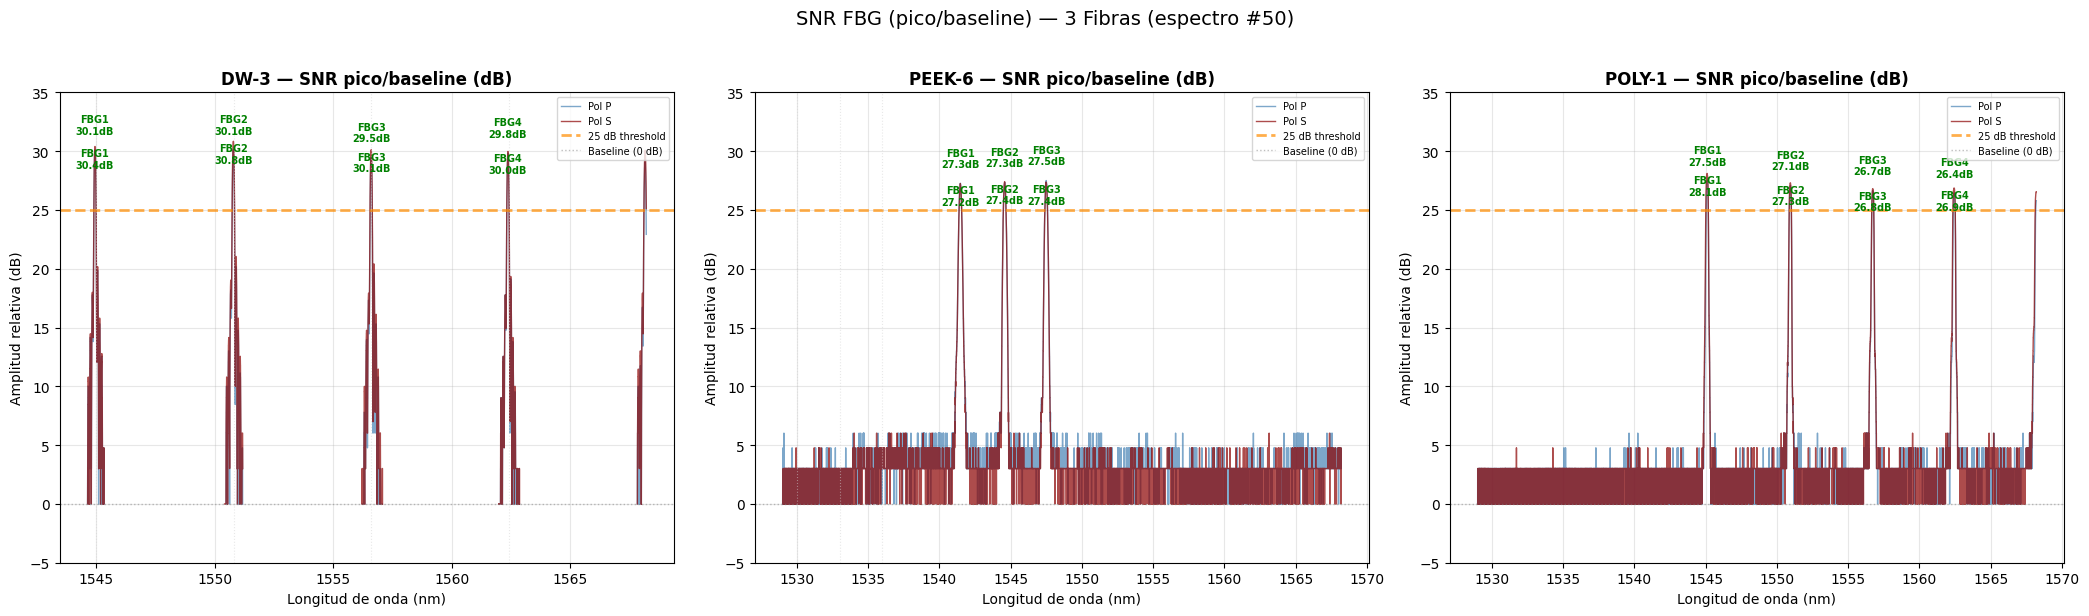

✅ Gráficos de SNR con eje λ generados
   ⚠️ SNR = 10·log₁₀(pico/baseline_local), NO reflectividad absoluta


In [12]:
if data_spectrum is not None and 'quality_results' in locals():
    # ══════════════════════════════════════════════════════════════════════
    # Plot v2: Espectros en dB con eje de longitud de onda
    # ══════════════════════════════════════════════════════════════════════

    n_channels_plot = min(n_chan, 3)
    fig, axes = plt.subplots(1, n_channels_plot, figsize=(7 * n_channels_plot, 6))
    if n_channels_plot == 1:
        axes = [axes]

    wavelength_axis = LAMBDA_START_NM + np.arange(n_puntos) * dlam_nm_per_pt

    for i, fiber_name in enumerate(['DW-3', 'PEEK-6', 'POLY-1'][:n_channels_plot]):
        if fiber_name not in quality_results:
            continue
        ax = axes[i]
        ch = list(channel_names.values()).index(fiber_name)

        for pol_idx, pol_name in enumerate(pol_labels):
            signal = spectrum_wav[idx_espectro, pol_idx, ch, :]
            bl_glob = global_baseline(signal)

            with np.errstate(divide="ignore", invalid="ignore"):
                signal_db = np.where(signal > 0,
                                     10.0 * np.log10(signal / bl_glob), np.nan)

            color = 'steelblue' if pol_idx == 0 else 'darkred'
            ax.plot(wavelength_axis, signal_db, color=color,
                    linewidth=1.0, alpha=0.7, label=pol_name)

            # Anotar picos válidos
            peaks = fbg_analysis_results[fiber_name][pol_name]
            valid = [p for p in peaks
                     if EDGE_MARGIN_PTS < p['peak_idx'] < (n_puntos - EDGE_MARGIN_PTS)]
            for j, peak in enumerate(valid, 1):
                key = (j, pol_name)
                if key not in quality_results[fiber_name]:
                    continue
                r = quality_results[fiber_name][key]
                lam = r['lambda_nm']
                snr = r['snr_db']
                if not np.isnan(snr):
                    y_db = signal_db[r['peak_idx']]
                    txt_col = "green" if snr >= SNR_THRESH_DB else "red"
                    y_off = 1.2 if pol_idx == 0 else -2.0
                    ax.text(lam, y_db + y_off,
                            f"FBG{j}\n{snr:.1f}dB",
                            ha="center", va="bottom", fontsize=7,
                            color=txt_col, fontweight="bold")

        # Threshold y baseline
        ax.axhline(SNR_THRESH_DB, color='darkorange', linestyle='--',
                   linewidth=2, alpha=0.7, label=f'{SNR_THRESH_DB:.0f} dB threshold')
        ax.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5,
                   label='Baseline (0 dB)')

        # Marcar longitudes de onda de diseño
        for wl in DESIGN_WAVELENGTHS.get(fiber_name, []):
            ax.axvline(wl, color='lightgray', linestyle=':', linewidth=0.8, alpha=0.5)

        ax.set_title(f'{fiber_name} — SNR pico/baseline (dB)', fontsize=12, fontweight='bold')
        ax.set_xlabel('Longitud de onda (nm)', fontsize=10)
        ax.set_ylabel('Amplitud relativa (dB)', fontsize=10)
        ax.set_ylim(-5, SNR_THRESH_DB + 10)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, loc='upper right')

    plt.suptitle(f'SNR FBG (pico/baseline) — 3 Fibras (espectro #{idx_espectro})',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    print("✅ Gráficos de SNR con eje λ generados")
    print("   ⚠️ SNR = 10·log₁₀(pico/baseline_local), NO reflectividad absoluta")

## 7️⃣ Tablas Resumen: Calidad por Sensor + Cross-Polarización

Tres tablas:
1. **Métricas por sensor/polarización**: λ_B, FWHM, BW@20dB, SF, Amp, SNR, SLSR, d_SL, SAR, L
2. **Cross-polarización**: birrefringencia (Δλ P−S), PDL
3. **Promedios por fibra**: resumen rápido de calidad

In [13]:
if data_spectrum is not None and 'quality_results' in locals():
    # ══════════════════════════════════════════════════════════════════════
    # Tabla resumen v2: por sensor + cross-pol + spacing
    # ══════════════════════════════════════════════════════════════════════

    # ── 1) Tabla detallada por sensor/polarización ────────────────────
    rows = []
    for fiber_name in ['DW-3', 'PEEK-6', 'POLY-1']:
        if fiber_name not in quality_results:
            continue
        for pol_name in pol_labels:
            peaks = fbg_analysis_results.get(fiber_name, {}).get(pol_name, [])
            valid = [p for p in peaks
                     if EDGE_MARGIN_PTS < p['peak_idx'] < (n_puntos - EDGE_MARGIN_PTS)]

            # Calcular spacing entre picos consecutivos
            lambdas = []
            for i in range(1, len(valid) + 1):
                key = (i, pol_name)
                if key in quality_results[fiber_name]:
                    lambdas.append(quality_results[fiber_name][key]['lambda_nm'])
                else:
                    lambdas.append(np.nan)

            for i in range(1, len(valid) + 1):
                key = (i, pol_name)
                if key not in quality_results[fiber_name]:
                    continue
                r = quality_results[fiber_name][key]

                # Spacing al pico anterior
                spacing_nm = np.nan
                if i > 1 and not np.isnan(lambdas[i - 1]) and not np.isnan(lambdas[i - 2]):
                    spacing_nm = lambdas[i - 1] - lambdas[i - 2]

                def fv(v, fmt_str):
                    return fmt_str.format(v) if not (isinstance(v, float) and np.isnan(v)) else ''

                rows.append({
                    'Fibra': fiber_name,
                    'FBG': i,
                    'Pol': pol_name.split()[-1],
                    'peak_idx': r['peak_idx'],
                    'lambda_B_nm': round(r['lambda_nm'], 3),
                    'spacing_nm': round(spacing_nm, 3) if not np.isnan(spacing_nm) else '',
                    'FWHM_pm': round(r.get('bw_3db_pm', np.nan), 1) if not np.isnan(r.get('bw_3db_pm', np.nan)) else '',
                    'BW20_pm': round(r.get('bw_20db_pm', np.nan), 1) if not np.isnan(r.get('bw_20db_pm', np.nan)) else '',
                    'SF': round(r.get('shape_factor', np.nan), 2) if not np.isnan(r.get('shape_factor', np.nan)) else '',
                    'Amp_cts': round(r['peak_amp'], 0),
                    'SNR_dB': round(r['snr_db'], 1) if not np.isnan(r['snr_db']) else '',
                    'SLSR_dB': round(r['slsr_db'], 1) if not np.isnan(r['slsr_db']) else '',
                    'SLSR_ratio': round(r.get('slsr_ratio', np.nan), 1) if not np.isnan(r.get('slsr_ratio', np.nan)) else '',
                    'd_SL_nm': round(r.get('sidelobe_dist_nm', np.nan), 2) if not np.isnan(r.get('sidelobe_dist_nm', np.nan)) else '',
                    'SAR_pct': round(r.get('sar_pct', np.nan), 1) if not np.isnan(r.get('sar_pct', np.nan)) else '',
                    'L_mm': round(r['fbg_length_mm'], 2) if not np.isnan(r['fbg_length_mm']) else '',
                })

    df_sensor = pd.DataFrame(rows)

    # Display-friendly version
    print("=" * 150)
    print("📋 TABLA 1: MÉTRICAS POR SENSOR Y POLARIZACIÓN")
    print("=" * 150)
    cols_show = ['Fibra', 'FBG', 'Pol', 'lambda_B_nm', 'spacing_nm', 'FWHM_pm',
                 'BW20_pm', 'SF', 'Amp_cts', 'SNR_dB', 'SLSR_dB', 'd_SL_nm', 'SAR_pct', 'L_mm']
    print(df_sensor[cols_show].to_string(index=False))
    print("=" * 150)

    # ── 2) Cross-polarización ─────────────────────────────────────────
    if cross_pol:
        xp_rows = []
        for fiber_name in ['DW-3', 'PEEK-6', 'POLY-1']:
            if fiber_name not in cross_pol:
                continue
            for sensor_num, cp in sorted(cross_pol[fiber_name].items()):
                xp_rows.append({
                    'Fibra': fiber_name, 'FBG': sensor_num,
                    'lambda_mean_nm': round(cp['lambda_mean'], 3),
                    'birefringence_pm': round(cp['birefringence_pm'], 1),
                    'Amp_P': round(cp['amp_P'], 0),
                    'Amp_S': round(cp['amp_S'], 0),
                    'PDL_dB': round(cp['pdl_db'], 2) if not np.isnan(cp['pdl_db']) else '',
                })
        df_xpol = pd.DataFrame(xp_rows)
        print(f"\n{'='*90}")
        print("📋 TABLA 2: CROSS-POLARIZACIÓN (P vs S)")
        print("=" * 90)
        print(df_xpol.to_string(index=False))
        print("=" * 90)

    # ── 3) Promedios por fibra ────────────────────────────────────────
    avg_rows = []
    for fiber_name in ['DW-3', 'PEEK-6', 'POLY-1']:
        if fiber_name not in quality_results:
            continue
        vals = {'fwhm': [], 'bw20': [], 'sf': [], 'snr': [], 'slsr': [],
                'd_sl': [], 'sar': [], 'l_fbg': [], 'amp': []}
        for key, r in quality_results[fiber_name].items():
            for attr, dkey in [('fwhm', 'bw_3db_pm'), ('bw20', 'bw_20db_pm'),
                               ('sf', 'shape_factor'), ('snr', 'snr_db'),
                               ('slsr', 'slsr_db'), ('d_sl', 'sidelobe_dist_nm'),
                               ('sar', 'sar_pct'), ('l_fbg', 'fbg_length_mm'),
                               ('amp', 'peak_amp')]:
                v = r.get(dkey, np.nan)
                if not np.isnan(v):
                    vals[attr].append(v)

        def m(lst, fmt):
            return fmt.format(np.mean(lst)) if lst else 'N/A'
        def s(lst, fmt):
            return fmt.format(np.std(lst)) if len(lst) > 1 else '–'

        avg_rows.append({
            'Fibra': fiber_name,
            'N_sens': DESIGN_N_SENSORS[fiber_name],
            'FWHM (pm)': f"{m(vals['fwhm'],'{:.0f}')} ± {s(vals['fwhm'],'{:.0f}')}",
            'BW@20 (pm)': f"{m(vals['bw20'],'{:.0f}')} ± {s(vals['bw20'],'{:.0f}')}",
            'SF': m(vals['sf'], '{:.2f}'),
            'SNR (dB)': f"{m(vals['snr'],'{:.1f}')} ± {s(vals['snr'],'{:.1f}')}",
            'SLSR (dB)': f"{m(vals['slsr'],'{:.1f}')} ± {s(vals['slsr'],'{:.1f}')}",
            'SAR (%)': m(vals['sar'], '{:.1f}'),
        })

    df_avg = pd.DataFrame(avg_rows)
    print(f"\n{'='*110}")
    print("📋 TABLA 3: PROMEDIOS POR FIBRA (ambas polarizaciones)")
    print("=" * 110)
    print(df_avg.to_string(index=False))
    print("=" * 110)

    print("\n📐 CRITERIOS DE CALIDAD:")
    print(f"   • SNR > {SNR_THRESH_DB:.0f} dB | SLSR > {SLSR_THRESH_DB:.0f} dB | SAR < {SAR_THRESH_PCT:.0f}%")
    print(f"   • IL total < {IL_TOTAL_THRESH_DB:.1f} dB")

    # Guardar df_sensor para CSV
    df_summary = df_sensor

elif data_spectrum is not None:
    print("⚠️  Ejecuta primero las celdas de análisis de calidad")

📋 TABLA 1: MÉTRICAS POR SENSOR Y POLARIZACIÓN
 Fibra  FBG Pol  lambda_B_nm spacing_nm  FWHM_pm  BW20_pm   SF  Amp_cts  SNR_dB  SLSR_dB  d_SL_nm  SAR_pct  L_mm
  DW-3    1   P     1544.952                76.5    288.7 3.77   1030.0    30.1     10.4     0.12      0.2 22.50
  DW-3    2   P     1550.786      5.834     78.0    220.7 2.83   1030.0    30.1     10.0     0.12      0.8 22.23
  DW-3    3   P     1556.598      5.812     76.9    219.1 2.85    887.0    29.5      9.8     0.12      1.0 22.72
  DW-3    4   P     1562.367      5.769     80.1    227.4 2.84    962.0    29.8     10.7     0.12      0.4 22.01
  DW-3    1   S     1544.952                77.2    289.6 3.75   1095.0    30.4     10.4     0.12      2.0 22.30
  DW-3    2   S     1550.788      5.836     79.9    221.9 2.78   1212.0    30.8      9.9     0.12      0.8 21.74
  DW-3    3   S     1556.599      5.811     78.3    217.8 2.78   1029.0    30.1      9.8     0.12      0.2 22.33
  DW-3    4   S     1562.367      5.768     80.2  

### 7.1 Comparación Pol P vs Pol S por sensor

Para cada fibra, se superponen los espectros de Pol P y Pol S alrededor de cada sensor FBG.
Se anotan la birrefringencia (Δλ) y la diferencia de amplitud (PDL).
Esto permite evaluar si el efecto de la polarización es significativo para cada grating.

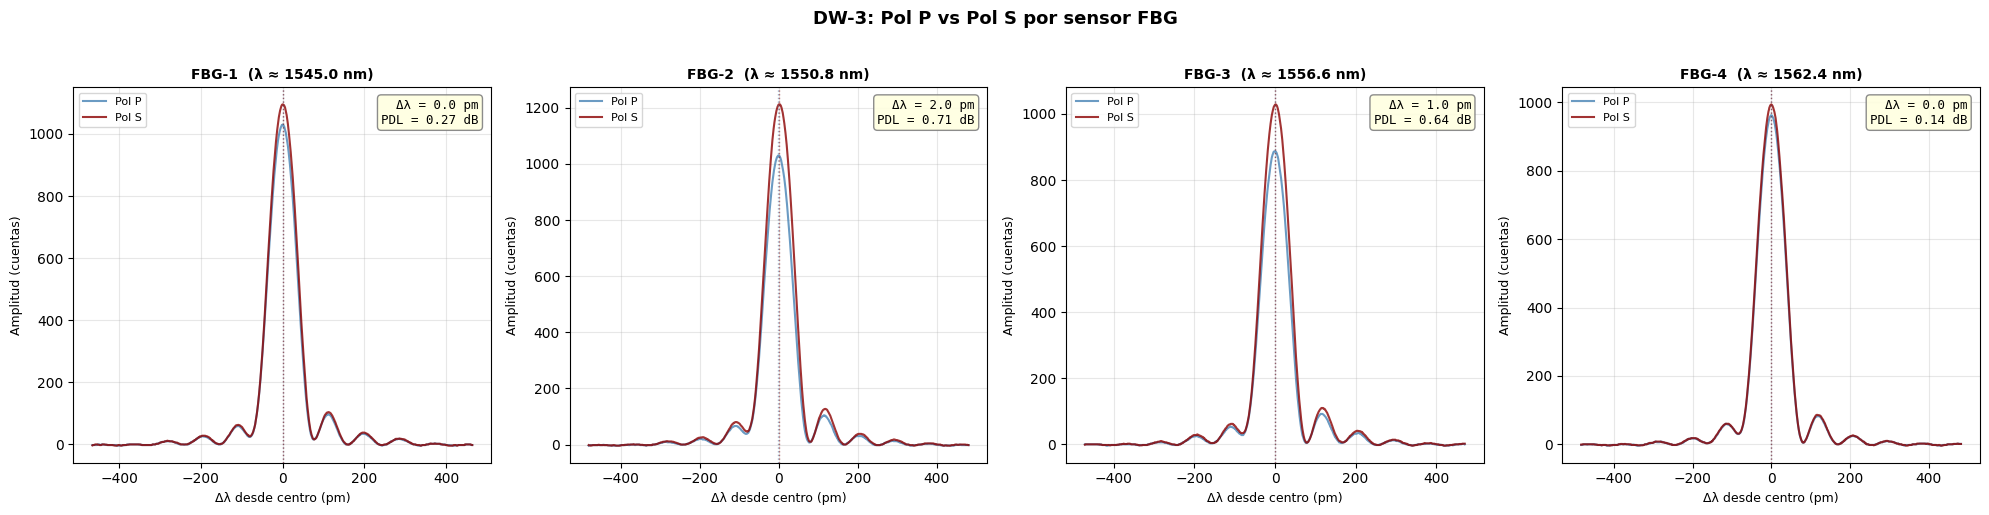

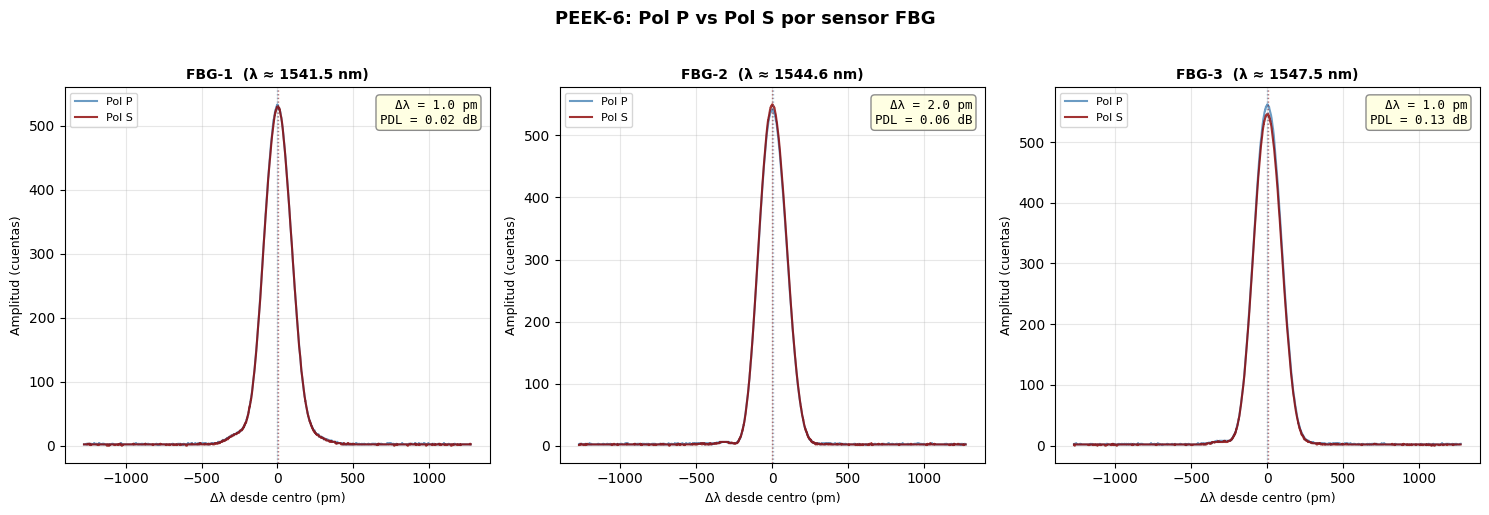

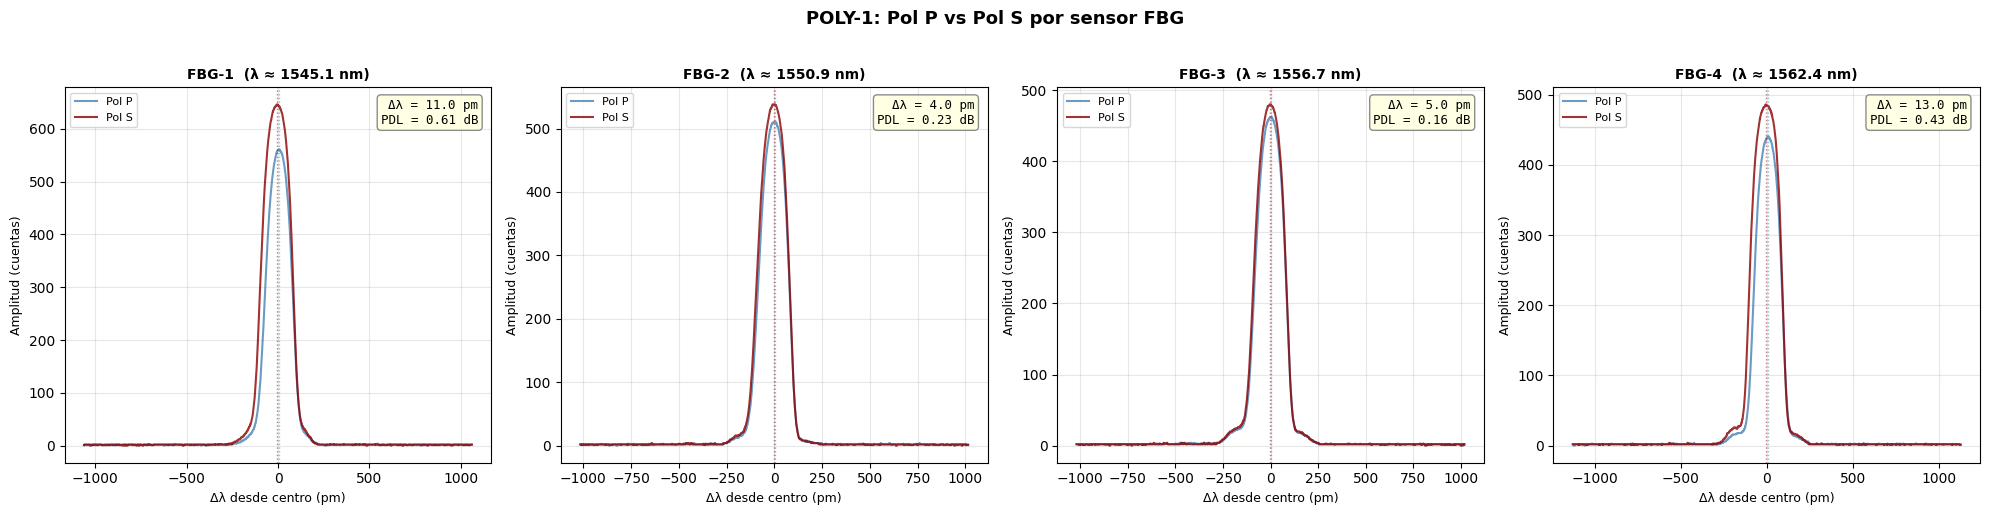

✅ Comparación P vs S completada
   • Δλ: birrefringencia entre polarizaciones
   • PDL: diferencia de amplitud (Polarization Dependent Loss)


In [14]:
if data_spectrum is not None and 'quality_results' in locals() and 'cross_pol' in locals():
    # ══════════════════════════════════════════════════════════════════════
    # Comparación Pol P vs Pol S: un subplot por sensor FBG
    # ══════════════════════════════════════════════════════════════════════

    for fiber_name in ['DW-3', 'PEEK-6', 'POLY-1']:
        if fiber_name not in cross_pol or not cross_pol[fiber_name]:
            continue

        ch = list(channel_names.values()).index(fiber_name)
        n_sensors = len(cross_pol[fiber_name])

        fig, axes = plt.subplots(1, n_sensors, figsize=(5 * n_sensors, 5))
        if n_sensors == 1:
            axes = [axes]

        sig_p = spectrum_wav[idx_espectro, 0, ch, :]
        sig_s = spectrum_wav[idx_espectro, 1, ch, :]

        for s_idx in range(n_sensors):
            sensor_num = s_idx + 1
            ax = axes[s_idx]
            cp = cross_pol[fiber_name].get(sensor_num)
            if cp is None:
                continue

            # Buscar picos de Pol P y Pol S para este sensor
            peaks_P = fbg_analysis_results[fiber_name].get('Pol P', [])
            peaks_S = fbg_analysis_results[fiber_name].get('Pol S', [])
            valid_P = [p for p in peaks_P
                       if EDGE_MARGIN_PTS < p['peak_idx'] < (n_puntos - EDGE_MARGIN_PTS)]
            valid_S = [p for p in peaks_S
                       if EDGE_MARGIN_PTS < p['peak_idx'] < (n_puntos - EDGE_MARGIN_PTS)]

            if s_idx >= len(valid_P) or s_idx >= len(valid_S):
                continue

            pk_P = valid_P[s_idx]
            pk_S = valid_S[s_idx]
            center_idx = int((pk_P['peak_idx'] + pk_S['peak_idx']) / 2)

            # Ventana de zoom: 6× FWHM máximo
            zoom = int(max(pk_P['fwhm'], pk_S['fwhm']) * 6)
            x0 = max(0, center_idx - zoom)
            x1 = min(n_puntos, center_idx + zoom)

            # Eje en longitud de onda relativa al centro (pm)
            lam_center = idx_to_wavelength(center_idx)
            x_pm = (np.arange(x0, x1) - center_idx) * dlam_nm_per_pt * 1e3

            ax.plot(x_pm, sig_p[x0:x1], color='steelblue', linewidth=1.5,
                    alpha=0.8, label='Pol P')
            ax.plot(x_pm, sig_s[x0:x1], color='darkred', linewidth=1.5,
                    alpha=0.8, label='Pol S')

            # Marcar picos
            for pk, col, lbl in [(pk_P, 'steelblue', 'P'), (pk_S, 'darkred', 'S')]:
                lam_pk = idx_to_wavelength(pk['peak_idx'])
                x_pk_pm = (pk['peak_idx'] - center_idx) * dlam_nm_per_pt * 1e3
                ax.axvline(x_pk_pm, color=col, linestyle=':', linewidth=1, alpha=0.5)

            # Anotaciones
            biref = cp['birefringence_pm']
            pdl = cp['pdl_db']
            info = f"Δλ = {biref:.1f} pm\nPDL = {pdl:.2f} dB" if not np.isnan(pdl) else f"Δλ = {biref:.1f} pm"
            ax.text(0.97, 0.97, info, transform=ax.transAxes,
                    fontsize=9, va='top', ha='right',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                              alpha=0.9, edgecolor='gray'),
                    fontfamily='monospace')

            ax.set_title(f'FBG-{sensor_num}  (λ ≈ {lam_center:.1f} nm)',
                         fontsize=10, fontweight='bold')
            ax.set_xlabel('Δλ desde centro (pm)', fontsize=9)
            ax.set_ylabel('Amplitud (cuentas)', fontsize=9)
            ax.legend(fontsize=8, loc='upper left')
            ax.grid(True, alpha=0.3)

        plt.suptitle(f'{fiber_name}: Pol P vs Pol S por sensor FBG',
                     fontsize=13, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

    print("✅ Comparación P vs S completada")
    print("   • Δλ: birrefringencia entre polarizaciones")
    print("   • PDL: diferencia de amplitud (Polarization Dependent Loss)")

### 7.2 Comparación entre sensores: Métricas de calidad

Barras agrupadas comparando FWHM, SNR, SLSR y SAR para cada sensor de cada fibra,
con Pol P y Pol S lado a lado. Permite identificar rápidamente sensores con calidad
inferior o variabilidad excesiva dentro de una misma fibra.

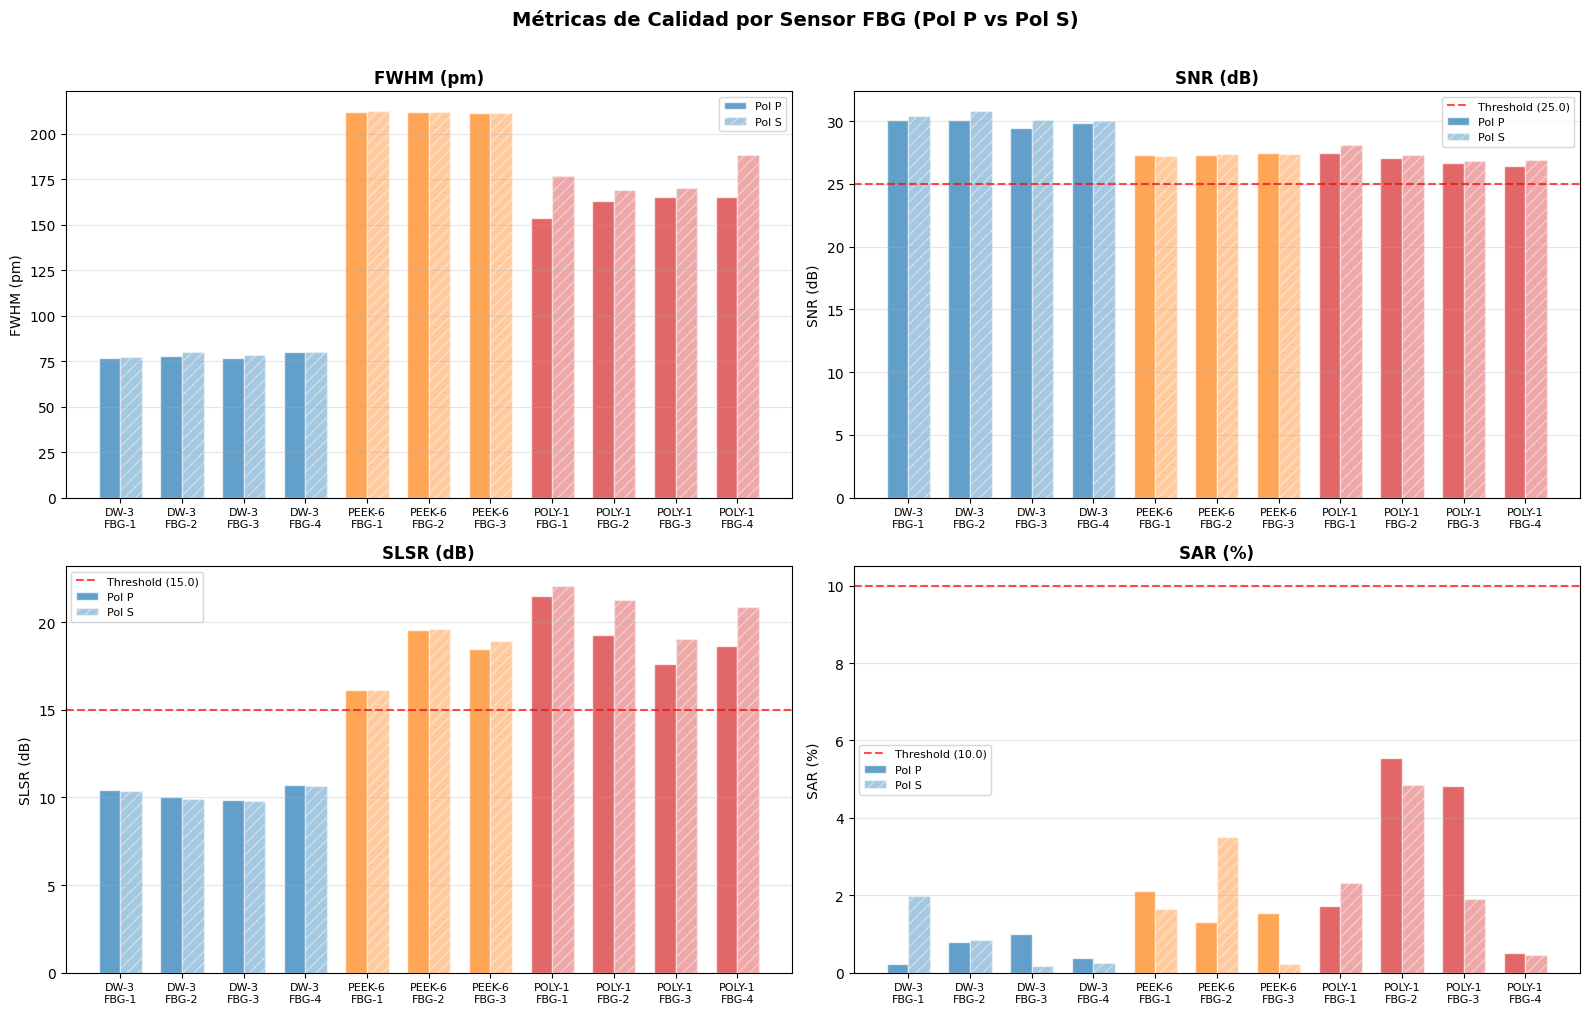

✅ Barras comparativas inter-sensor generadas
   Barras sólidas = Pol P | Barras rayadas = Pol S
   Línea roja = threshold de calidad


In [15]:
if data_spectrum is not None and 'quality_results' in locals():
    # ══════════════════════════════════════════════════════════════════════
    # Barras comparativas: métricas de calidad por sensor (P y S)
    # ══════════════════════════════════════════════════════════════════════

    metrics_to_plot = [
        ('bw_3db_pm',  'FWHM (pm)',  None, None),
        ('snr_db',   'SNR (dB)',   SNR_THRESH_DB, 'min'),
        ('slsr_db',  'SLSR (dB)',  SLSR_THRESH_DB, 'min'),
        ('sar_pct',  'SAR (%)',    SAR_THRESH_PCT, 'max'),
    ]

    colors_fiber = {'DW-3': 'tab:blue', 'PEEK-6': 'tab:orange', 'POLY-1': 'tab:red'}

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for ax_idx, (mkey, mlabel, thresh, thresh_type) in enumerate(metrics_to_plot):
        ax = axes[ax_idx]

        # Recoger datos: etiquetas, valores P, valores S
        labels = []
        vals_p = []
        vals_s = []
        fiber_colors = []

        for fiber_name in ['DW-3', 'PEEK-6', 'POLY-1']:
            if fiber_name not in quality_results:
                continue
            n_design = DESIGN_N_SENSORS[fiber_name]
            for s in range(1, n_design + 1):
                labels.append(f"{fiber_name}\nFBG-{s}")
                fiber_colors.append(colors_fiber[fiber_name])

                rp = quality_results[fiber_name].get((s, 'Pol P'), {})
                rs = quality_results[fiber_name].get((s, 'Pol S'), {})
                vp = rp.get(mkey, np.nan)
                vs = rs.get(mkey, np.nan)
                vals_p.append(vp if not np.isnan(vp) else 0)
                vals_s.append(vs if not np.isnan(vs) else 0)

        x = np.arange(len(labels))
        w = 0.35

        bars_p = ax.bar(x - w/2, vals_p, w, label='Pol P',
                        color=[c for c in fiber_colors], alpha=0.7, edgecolor='white')
        bars_s = ax.bar(x + w/2, vals_s, w, label='Pol S',
                        color=[c for c in fiber_colors], alpha=0.4, edgecolor='white',
                        hatch='///')

        # Threshold line
        if thresh is not None:
            ax.axhline(thresh, color='red', linestyle='--', linewidth=1.5,
                       alpha=0.7, label=f'Threshold ({thresh})')

        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=8)
        ax.set_ylabel(mlabel, fontsize=10)
        ax.set_title(mlabel, fontsize=12, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, axis='y', alpha=0.3)

    plt.suptitle('Métricas de Calidad por Sensor FBG (Pol P vs Pol S)',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    print("✅ Barras comparativas inter-sensor generadas")
    print("   Barras sólidas = Pol P | Barras rayadas = Pol S")
    print("   Línea roja = threshold de calidad")

## 8️⃣ Visualización Comparativa: Picos Superpuestos

Superpone el primer pico de cada fibra (media P+S) con eje X en pm (Δλ desde centro).
Los recuadros laterales muestran todas las métricas v2 incluyendo BW@20dB y Shape Factor.

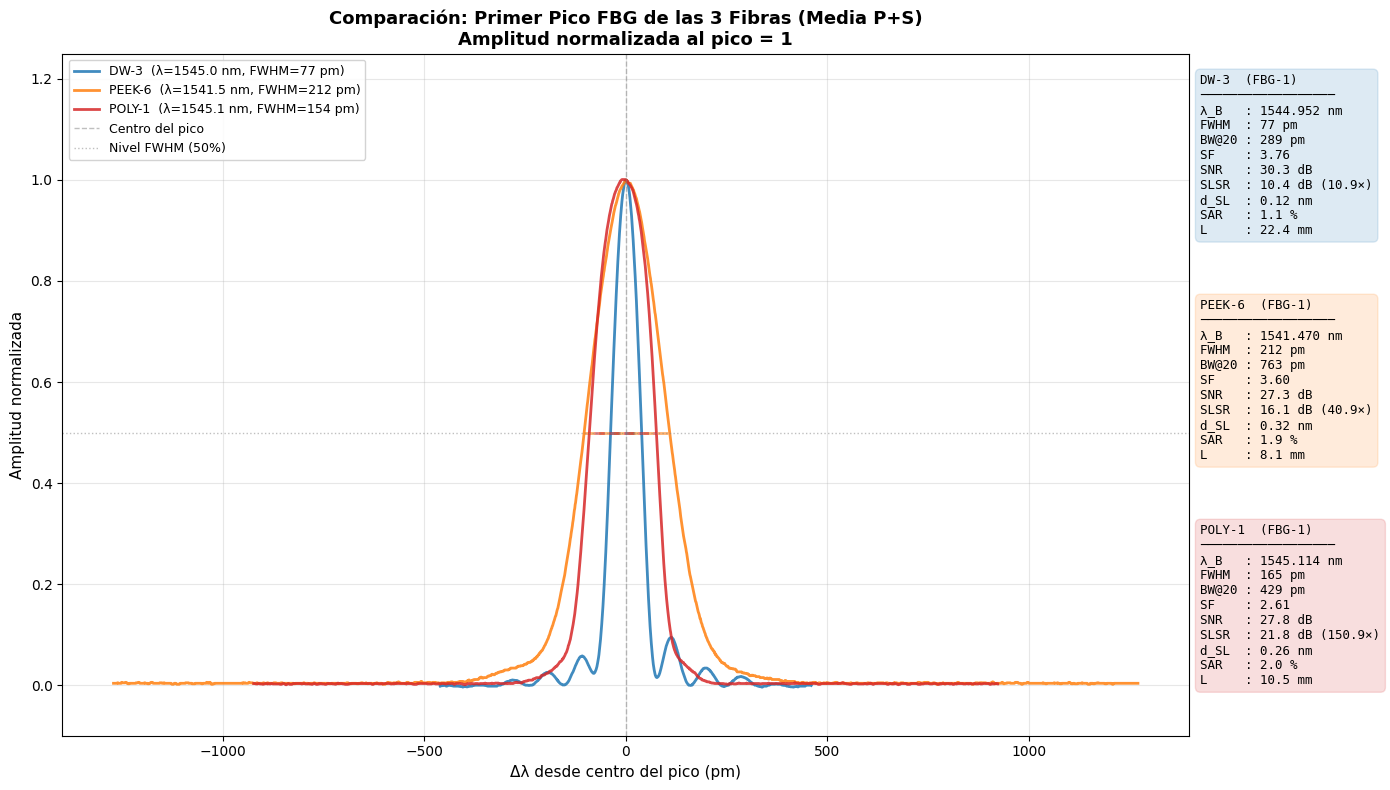

✅ Comparación normalizada con métricas v2 completada
   Resolución: 1.00 pm/pt | Eje X en pm


In [16]:
if data_spectrum is not None and 'quality_results' in locals():
    fig, ax = plt.subplots(figsize=(14, 8))

    colors_fiber = {'DW-3': 'tab:blue', 'PEEK-6': 'tab:orange', 'POLY-1': 'tab:red'}
    box_y_positions = {'DW-3': 0.97, 'PEEK-6': 0.64, 'POLY-1': 0.31}

    for fiber_name in ['DW-3', 'PEEK-6', 'POLY-1']:
        if fiber_name not in fbg_analysis_results or fiber_name not in quality_results:
            continue

        peaks_p = fbg_analysis_results[fiber_name]['Pol P']
        valid_p = [p for p in peaks_p
                   if EDGE_MARGIN_PTS < p['peak_idx'] < (n_puntos - EDGE_MARGIN_PTS)]
        if len(valid_p) == 0:
            continue

        peak = valid_p[0]  # Primer sensor válido
        ch = list(channel_names.values()).index(fiber_name)
        sig_p = spectrum_wav[idx_espectro, 0, ch, :]
        sig_s = spectrum_wav[idx_espectro, 1, ch, :]
        signal = (sig_p + sig_s) / 2.0

        peak_idx = peak['peak_idx']
        zoom = int(peak['fwhm'] * 6)
        x0 = max(0, peak_idx - zoom)
        x1 = min(n_puntos, peak_idx + zoom)

        # Eje en Δλ (pm) respecto al centro
        x_pm = (np.arange(x0, x1) - peak_idx) * dlam_nm_per_pt * 1e3
        y_norm = signal[x0:x1] / signal[peak_idx]

        color = colors_fiber[fiber_name]
        fwhm_pm = peak['fwhm'] * dlam_nm_per_pt * 1e3
        lam_b = idx_to_wavelength(peak_idx)

        ax.plot(x_pm, y_norm, color=color, linewidth=2, alpha=0.85,
                label=f"{fiber_name}  (λ={lam_b:.1f} nm, FWHM={fwhm_pm:.0f} pm)")

        # FWHM line
        l_ip_pm = (peak['left_ip'] - peak_idx) * dlam_nm_per_pt * 1e3
        r_ip_pm = (peak['right_ip'] - peak_idx) * dlam_nm_per_pt * 1e3
        ax.hlines(0.5, l_ip_pm, r_ip_pm, color=color, linestyle='--',
                  linewidth=2, alpha=0.6)

        # Métricas promedio P+S
        mp = quality_results[fiber_name].get((1, 'Pol P'), {})
        ms = quality_results[fiber_name].get((1, 'Pol S'), {})

        def avg(key):
            vals = [m.get(key, np.nan) for m in [mp, ms]]
            vals = [v for v in vals if not np.isnan(v)]
            return np.mean(vals) if vals else np.nan

        snr     = avg('snr_db')
        slsr    = avg('slsr_db')
        slsr_r  = avg('slsr_ratio')
        d_sl    = avg('sidelobe_dist_nm')
        sar     = avg('sar_pct')
        l_fbg   = avg('fbg_length_mm')
        bw20    = avg('bw_20db_pm')
        sf      = avg('shape_factor')

        def fmt(v, fs):
            return fs.format(v) if not (isinstance(v, float) and np.isnan(v)) else "N/A"

        info = (
            f"{fiber_name}  (FBG-1)\n"
            f"──────────────────\n"
            f"λ_B   : {lam_b:.3f} nm\n"
            f"FWHM  : {fmt(avg('bw_3db_pm'),'{:.0f}')} pm\n"
            f"BW@20 : {fmt(bw20,'{:.0f}')} pm\n"
            f"SF    : {fmt(sf,'{:.2f}')}\n"
            f"SNR   : {fmt(snr,'{:.1f}')} dB\n"
            f"SLSR  : {fmt(slsr,'{:.1f}')} dB ({fmt(slsr_r,'{:.1f}')}×)\n"
            f"d_SL  : {fmt(d_sl,'{:.2f}')} nm\n"
            f"SAR   : {fmt(sar,'{:.1f}')} %\n"
            f"L     : {fmt(l_fbg,'{:.1f}')} mm"
        )

        ax.text(1.01, box_y_positions[fiber_name], info,
                transform=ax.transAxes, fontsize=9, va='top',
                bbox=dict(boxstyle='round,pad=0.4', facecolor=color,
                          alpha=0.15, edgecolor=color),
                color='black', fontfamily='monospace')

    ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5,
               label='Centro del pico')
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5,
               label='Nivel FWHM (50%)')

    ax.set_xlabel('Δλ desde centro del pico (pm)', fontsize=11)
    ax.set_ylabel('Amplitud normalizada', fontsize=11)
    ax.set_ylim(-0.1, 1.25)
    ax.set_title('Comparación: Primer Pico FBG de las 3 Fibras (Media P+S)\n'
                 'Amplitud normalizada al pico = 1', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='upper left', framealpha=0.85)

    plt.tight_layout()
    plt.show()

    print("✅ Comparación normalizada con métricas v2 completada")
    print(f"   Resolución: {dlam_nm_per_pt*1e3:.2f} pm/pt | Eje X en pm")

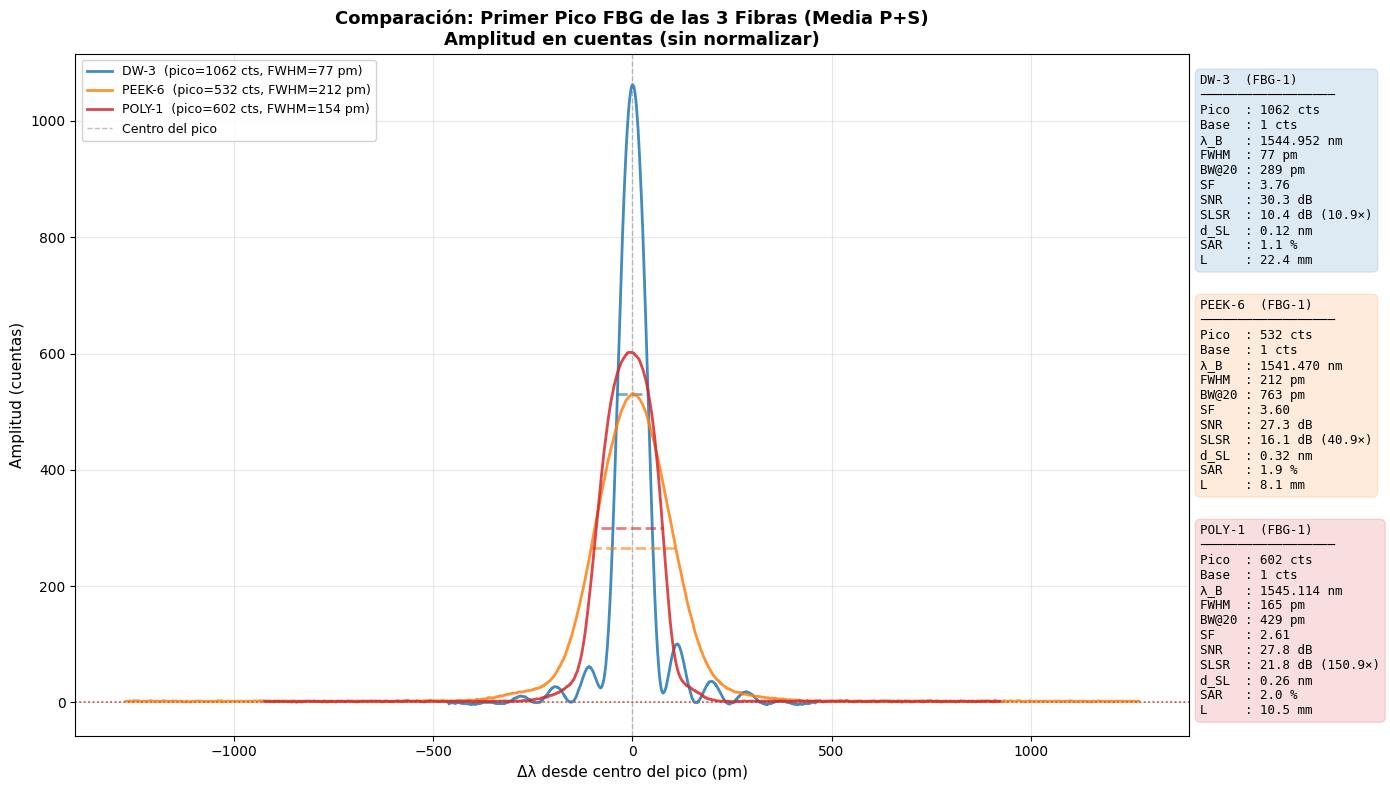

✅ Comparación en cuentas con métricas v2 completada
   Resolución: 1.00 pm/pt | Eje X en pm


In [17]:
if data_spectrum is not None and 'quality_results' in locals():
    fig, ax = plt.subplots(figsize=(14, 8))

    colors_fiber = {'DW-3': 'tab:blue', 'PEEK-6': 'tab:orange', 'POLY-1': 'tab:red'}
    box_y_positions = {'DW-3': 0.97, 'PEEK-6': 0.64, 'POLY-1': 0.31}

    for fiber_name in ['DW-3', 'PEEK-6', 'POLY-1']:
        if fiber_name not in fbg_analysis_results or fiber_name not in quality_results:
            continue

        peaks_p = fbg_analysis_results[fiber_name]['Pol P']
        valid_p = [p for p in peaks_p
                   if EDGE_MARGIN_PTS < p['peak_idx'] < (n_puntos - EDGE_MARGIN_PTS)]
        if len(valid_p) == 0:
            continue

        peak = valid_p[0]
        ch = list(channel_names.values()).index(fiber_name)
        sig_p = spectrum_wav[idx_espectro, 0, ch, :]
        sig_s = spectrum_wav[idx_espectro, 1, ch, :]
        signal = (sig_p + sig_s) / 2.0

        peak_idx = peak['peak_idx']
        zoom = int(peak['fwhm'] * 6)
        x0 = max(0, peak_idx - zoom)
        x1 = min(n_puntos, peak_idx + zoom)

        # Eje en Δλ (pm)
        x_pm = (np.arange(x0, x1) - peak_idx) * dlam_nm_per_pt * 1e3
        y_counts = signal[x0:x1]

        color = colors_fiber[fiber_name]
        fwhm_pm = peak['fwhm'] * dlam_nm_per_pt * 1e3
        peak_amp = signal[peak_idx]
        lam_b = idx_to_wavelength(peak_idx)

        ax.plot(x_pm, y_counts, color=color, linewidth=2, alpha=0.85,
                label=f"{fiber_name}  (pico={peak_amp:.0f} cts, FWHM={fwhm_pm:.0f} pm)")

        # FWHM line
        half_amp = peak_amp / 2.0
        l_ip_pm = (peak['left_ip'] - peak_idx) * dlam_nm_per_pt * 1e3
        r_ip_pm = (peak['right_ip'] - peak_idx) * dlam_nm_per_pt * 1e3
        ax.hlines(half_amp, l_ip_pm, r_ip_pm, color=color, linestyle='--',
                  linewidth=2, alpha=0.6)

        # Métricas promedio P+S
        mp = quality_results[fiber_name].get((1, 'Pol P'), {})
        ms = quality_results[fiber_name].get((1, 'Pol S'), {})

        def avg(key):
            vals = [m.get(key, np.nan) for m in [mp, ms]]
            vals = [v for v in vals if not np.isnan(v)]
            return np.mean(vals) if vals else np.nan

        bl      = avg('baseline_loc')
        snr     = avg('snr_db')
        slsr    = avg('slsr_db')
        slsr_r  = avg('slsr_ratio')
        d_sl    = avg('sidelobe_dist_nm')
        sar     = avg('sar_pct')
        l_fbg   = avg('fbg_length_mm')
        bw20    = avg('bw_20db_pm')
        sf      = avg('shape_factor')

        # Baseline line
        if not np.isnan(bl):
            ax.axhline(bl, color=color, linestyle=':', linewidth=1.2, alpha=0.5)

        def fmt(v, fs):
            return fs.format(v) if not (isinstance(v, float) and np.isnan(v)) else "N/A"

        info = (
            f"{fiber_name}  (FBG-1)\n"
            f"──────────────────\n"
            f"Pico  : {peak_amp:.0f} cts\n"
            f"Base  : {fmt(bl,'{:.0f}')} cts\n"
            f"λ_B   : {lam_b:.3f} nm\n"
            f"FWHM  : {fmt(avg('bw_3db_pm'),'{:.0f}')} pm\n"
            f"BW@20 : {fmt(bw20,'{:.0f}')} pm\n"
            f"SF    : {fmt(sf,'{:.2f}')}\n"
            f"SNR   : {fmt(snr,'{:.1f}')} dB\n"
            f"SLSR  : {fmt(slsr,'{:.1f}')} dB ({fmt(slsr_r,'{:.1f}')}×)\n"
            f"d_SL  : {fmt(d_sl,'{:.2f}')} nm\n"
            f"SAR   : {fmt(sar,'{:.1f}')} %\n"
            f"L     : {fmt(l_fbg,'{:.1f}')} mm"
        )

        ax.text(1.01, box_y_positions[fiber_name], info,
                transform=ax.transAxes, fontsize=9, va='top',
                bbox=dict(boxstyle='round,pad=0.4', facecolor=color,
                          alpha=0.15, edgecolor=color),
                color='black', fontfamily='monospace')

    ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5,
               label='Centro del pico')

    ax.set_xlabel('Δλ desde centro del pico (pm)', fontsize=11)
    ax.set_ylabel('Amplitud (cuentas)', fontsize=11)
    ax.set_title('Comparación: Primer Pico FBG de las 3 Fibras (Media P+S)\n'
                 'Amplitud en cuentas (sin normalizar)', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='upper left', framealpha=0.85)

    plt.tight_layout()
    plt.show()

    print("✅ Comparación en cuentas con métricas v2 completada")
    print(f"   Resolución: {dlam_nm_per_pt*1e3:.2f} pm/pt | Eje X en pm")

## 9️⃣ Insertion Loss Acumulativa del Array FBG

### Concepto
En un array de FBGs en serie, cada grating refleja una fracción de la luz.
La luz que alcanza el FBG-$j$ debe atravesar todos los gratings anteriores **dos veces**
(ida y vuelta). Si cada FBG tiene reflectividad $R_i$:

$$P_{\text{reflejada},j} = P_0 \cdot R_j \cdot \prod_{i<j}(1-R_i)^2$$

La **insertion loss acumulativa** es la pérdida total que sufre la señal al
atravesar todo el array:

$$\text{IL}_{\text{total}} = -10 \cdot \log_{10}\left(\frac{\text{Amp}_{\text{último}}}{\text{Amp}_{\text{primero}}}\right) \div 2$$

(dividimos por 2 porque es doble paso — ida y vuelta a través de los gratings intermedios)

**Criterio de aceptación:** IL total < 1.5 dB

### Método
1. **Decaimiento progresivo de amplitud**: comparar picos consecutivos (media P+S)
2. **Análisis del baseline**: si la línea base cae a lo largo del array, indica pérdida óptica
3. **Estimación de IL acumulativa** por fibra

/tmp/vgarciap/ipykernel_2004828/1586146243.py:111: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/afs/cern.ch/user/v/vgarciap/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


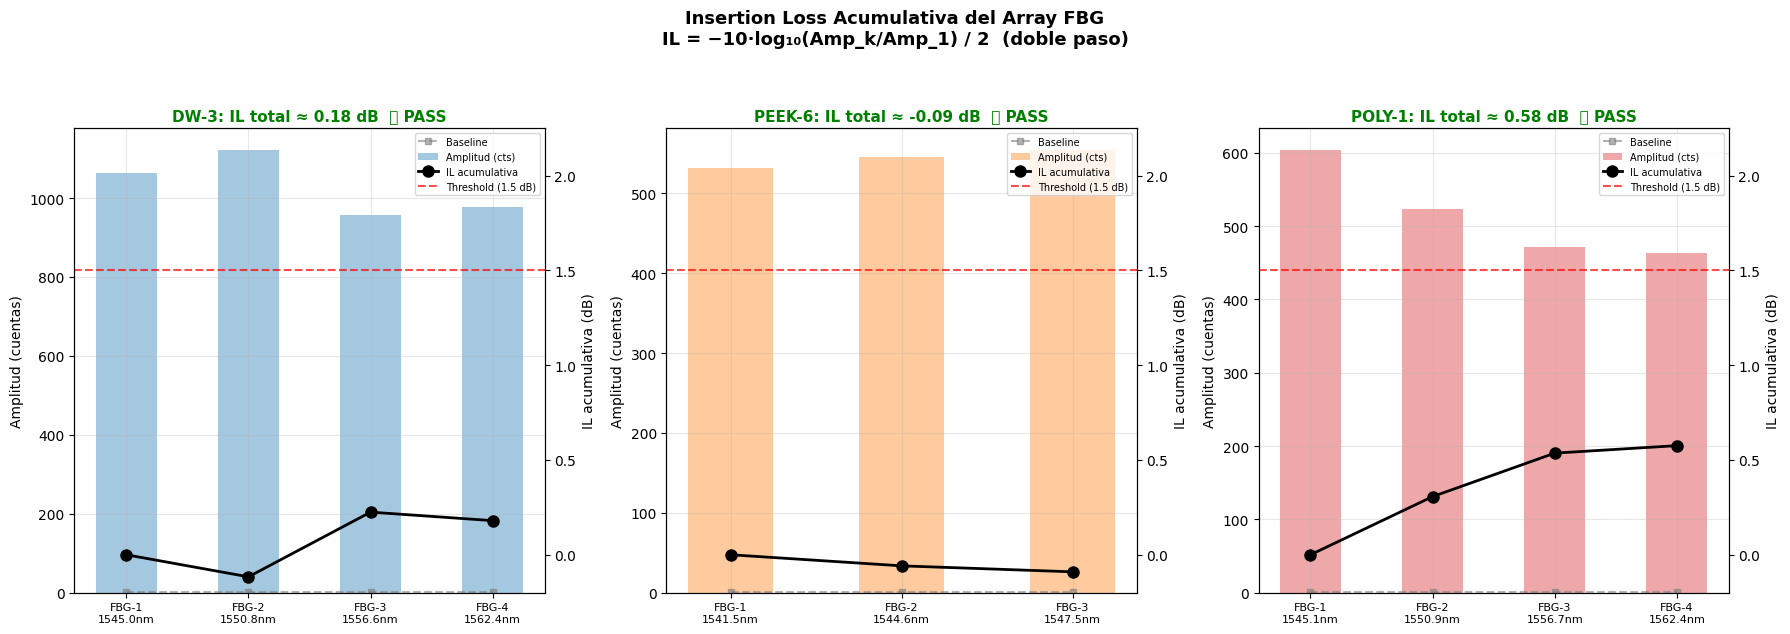

📊 INSERTION LOSS ACUMULATIVA POR FIBRA:
Fibra      N_sens      Amp_1    Amp_N   IL_total     Criterio
────────────────────────────────────────────────────────────
DW-3       4            1062      978      0.180   ✅ < 1.5 dB
PEEK-6     3             532      554     -0.090   ✅ < 1.5 dB
POLY-1     4             604      463      0.575   ✅ < 1.5 dB

⚠️  NOTA: Esta es una estimación INDIRECTA de la IL.
   Asume gratings similares; variaciones de R entre FBGs afectan la estimación.
   Una medida directa requeriría fuente broadband + powermeter en transmisión.


In [18]:
if data_spectrum is not None and 'quality_results' in locals():
    # ══════════════════════════════════════════════════════════════════════
    # Insertion Loss acumulativa — estimación desde amplitudes reflejadas
    # ══════════════════════════════════════════════════════════════════════

    colors_fiber = {'DW-3': 'tab:blue', 'PEEK-6': 'tab:orange', 'POLY-1': 'tab:red'}
    il_results = {}

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for fi, fiber_name in enumerate(['DW-3', 'PEEK-6', 'POLY-1']):
        if fiber_name not in quality_results:
            continue

        ax = axes[fi]
        ch = list(channel_names.values()).index(fiber_name)

        # Recoger amplitudes media P+S por sensor, ordenadas por λ
        sensor_data = []
        n_sens_max = max(k[0] for k in quality_results[fiber_name].keys())
        for s in range(1, n_sens_max + 1):
            rp = quality_results[fiber_name].get((s, 'Pol P'), {})
            rs = quality_results[fiber_name].get((s, 'Pol S'), {})
            amp_p = rp.get('peak_amp', np.nan)
            amp_s = rs.get('peak_amp', np.nan)
            lam = rp.get('lambda_nm', rs.get('lambda_nm', np.nan))
            bl_p = rp.get('baseline_loc', np.nan)
            bl_s = rs.get('baseline_loc', np.nan)
            vals = [v for v in [amp_p, amp_s] if not np.isnan(v)]
            bls = [v for v in [bl_p, bl_s] if not np.isnan(v)]
            if vals:
                sensor_data.append({
                    'sensor': s, 'lambda_nm': lam,
                    'amp_mean': np.mean(vals),
                    'bl_mean': np.mean(bls) if bls else np.nan,
                    'amp_p': amp_p, 'amp_s': amp_s
                })

        if len(sensor_data) < 2:
            ax.text(0.5, 0.5, 'Insuficientes sensores', transform=ax.transAxes,
                    ha='center', va='center')
            continue

        sensor_data.sort(key=lambda x: x['lambda_nm'])
        sensors = [d['sensor'] for d in sensor_data]
        amps = [d['amp_mean'] for d in sensor_data]
        bls = [d['bl_mean'] for d in sensor_data]
        lambdas = [d['lambda_nm'] for d in sensor_data]

        # IL acumulativa relativa al primer sensor
        amp0 = amps[0]
        il_cumulative = [0.0]  # FBG-1 → 0 dB
        for k in range(1, len(amps)):
            if amps[k] > 0 and amp0 > 0:
                # IL = -10·log10(Amp_k / Amp_1) / 2  (doble paso)
                il = -10.0 * np.log10(amps[k] / amp0) / 2.0
                il_cumulative.append(il)
            else:
                il_cumulative.append(np.nan)

        il_total = il_cumulative[-1] if not np.isnan(il_cumulative[-1]) else np.nan
        pass_il = (not np.isnan(il_total)) and (il_total < IL_TOTAL_THRESH_DB)

        il_results[fiber_name] = {
            'sensors': sensors, 'lambdas': lambdas,
            'amplitudes': amps, 'baselines': bls,
            'il_cumulative': il_cumulative, 'il_total': il_total,
            'pass_il': pass_il,
        }

        # ── Plot ──
        x = np.arange(len(sensors))
        lbls = [f'FBG-{s}\n{l:.1f}nm' for s, l in zip(sensors, lambdas)]

        color = colors_fiber[fiber_name]

        # Barras de amplitud
        ax2 = ax.twinx()
        ax.bar(x, amps, 0.5, color=color, alpha=0.4, label='Amplitud (cts)')

        # Línea de IL acumulativa
        ax2.plot(x, il_cumulative, 'ko-', linewidth=2, markersize=8, label='IL acumulativa')
        ax2.axhline(IL_TOTAL_THRESH_DB, color='red', linestyle='--', linewidth=1.5,
                    alpha=0.7, label=f'Threshold ({IL_TOTAL_THRESH_DB} dB)')
        ax2.set_ylabel('IL acumulativa (dB)', fontsize=10)
        ax2.set_ylim(-0.2, max(IL_TOTAL_THRESH_DB * 1.5, max(c for c in il_cumulative if not np.isnan(c)) * 1.3 + 0.1) if any(not np.isnan(c) for c in il_cumulative) else 3.0)

        # Baselines (si hay tendencia)
        if all(not np.isnan(b) for b in bls):
            ax.plot(x, bls, 's--', color='gray', markersize=5, alpha=0.6, label='Baseline')

        ax.set_xticks(x)
        ax.set_xticklabels(lbls, fontsize=8)
        ax.set_ylabel('Amplitud (cuentas)', fontsize=10)

        result_str = f"✅ PASS" if pass_il else f"❌ FAIL"
        il_str = f"{il_total:.2f}" if not np.isnan(il_total) else "N/A"
        ax.set_title(f'{fiber_name}: IL total ≈ {il_str} dB  {result_str}',
                     fontsize=11, fontweight='bold',
                     color='green' if pass_il else 'red')

        # Combinar leyendas
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, fontsize=7, loc='upper right')
        ax.grid(True, alpha=0.3)

    plt.suptitle('Insertion Loss Acumulativa del Array FBG\n'
                 'IL = −10·log₁₀(Amp_k/Amp_1) / 2  (doble paso)',
                 fontsize=13, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

    # Resumen numérico
    print("📊 INSERTION LOSS ACUMULATIVA POR FIBRA:")
    print(f"{'Fibra':<10} {'N_sens':<8} {'Amp_1':>8} {'Amp_N':>8} {'IL_total':>10} {'Criterio':>12}")
    print("─" * 60)
    for fn in ['DW-3', 'PEEK-6', 'POLY-1']:
        if fn not in il_results:
            continue
        r = il_results[fn]
        a1 = r['amplitudes'][0]
        aN = r['amplitudes'][-1]
        il = r['il_total']
        ok = "✅ < 1.5 dB" if r['pass_il'] else "❌ > 1.5 dB"
        il_s = f"{il:.3f}" if not np.isnan(il) else "N/A"
        print(f"{fn:<10} {len(r['sensors']):<8} {a1:>8.0f} {aN:>8.0f} {il_s:>10} {ok:>12}")

    print(f"\n⚠️  NOTA: Esta es una estimación INDIRECTA de la IL.")
    print(f"   Asume gratings similares; variaciones de R entre FBGs afectan la estimación.")
    print(f"   Una medida directa requeriría fuente broadband + powermeter en transmisión.")

## 🔟 QC Defense: Justificación de Criterios de Calidad

Panel de 6 gráficos que muestran cada parámetro de control de calidad con su
criterio de aceptación. Para cada sensor se indica PASS/FAIL, permitiendo
defender las decisiones de QC en un informe técnico.

| Parámetro | Criterio | Justificación |
|-----------|----------|---------------|
| SNR | > 25 dB | Mínimo para precisión de pico < 1 pm (spec: −15 dBm → 0.05 pm) |
| SLSR | > 15 dB | FBG uniforme teórico: 13.3 dB. Margen para multipath / crosstalk |
| SAR | < 10% | Asimetría excesiva indica gradiente de strain o defecto de escritura |
| FWHM | 40–1500 pm | Rango soportado por el interrogador I4G-16 |
| SF | < 5.0 | SF > 5 indica lóbulos excesivos o chirp no controlado |
| IL total | < 1.5 dB | Estándar para arrays FBG en aplicaciones industriales |

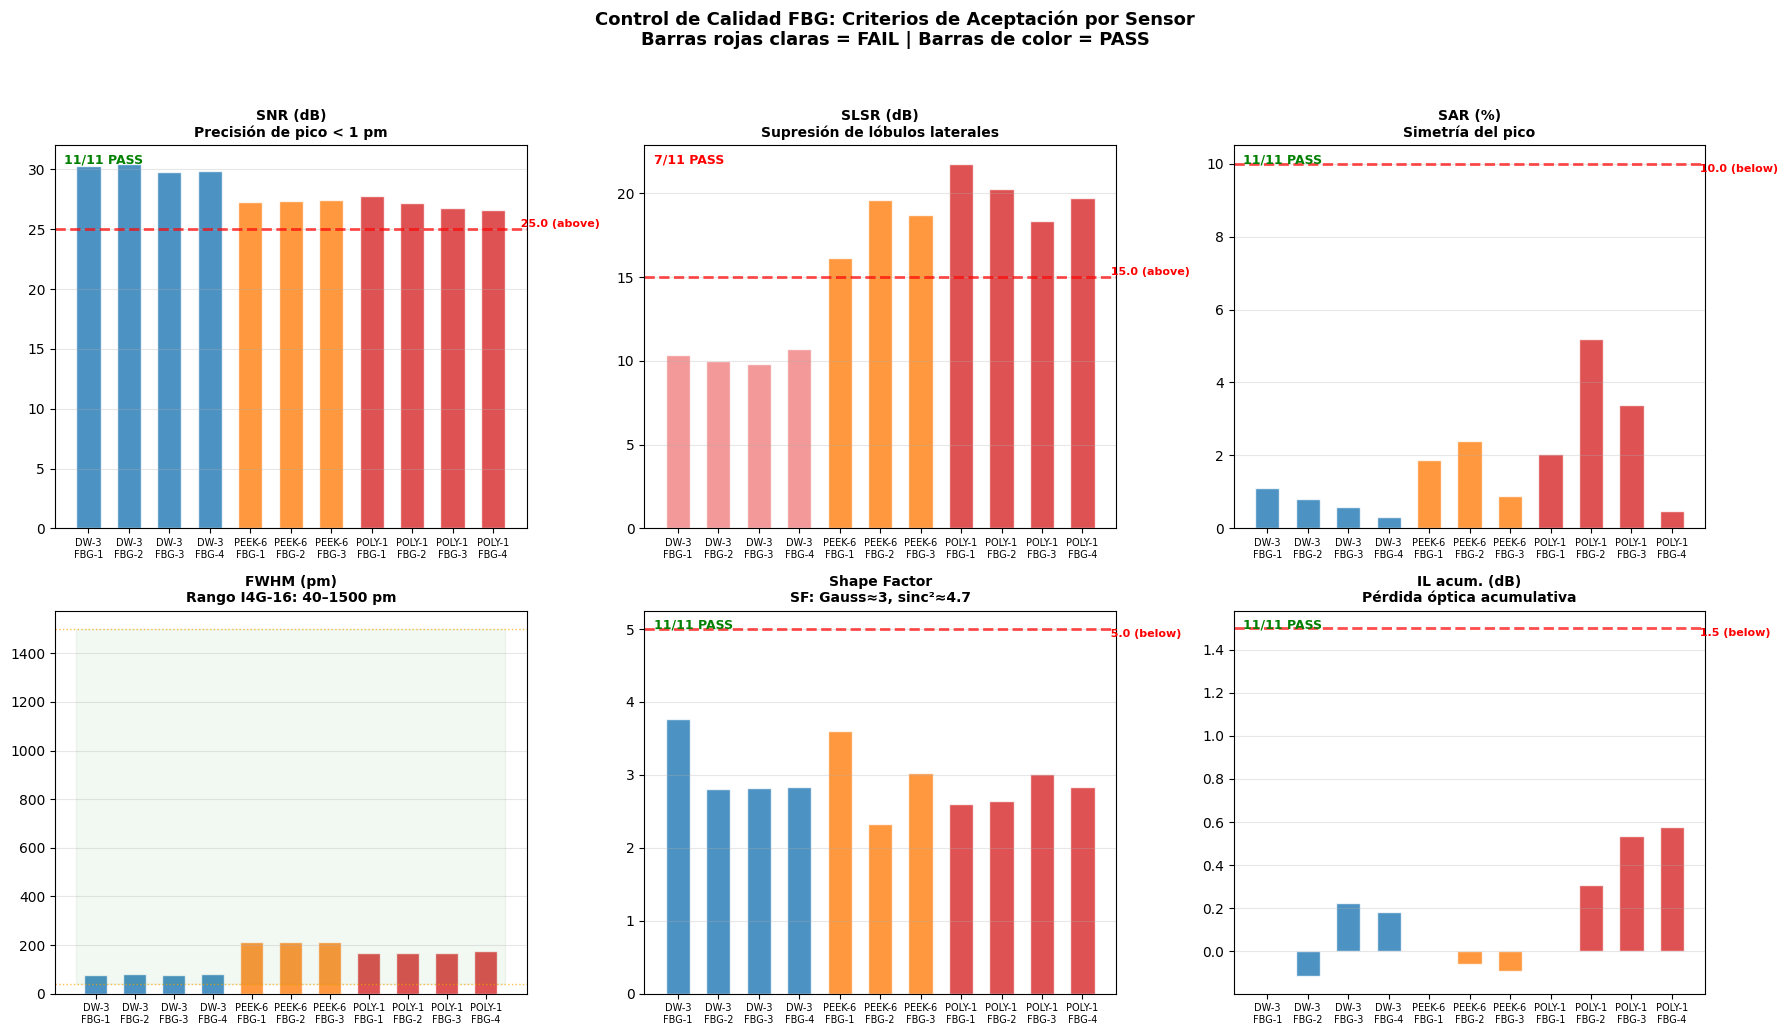

📋 RESUMEN QC POR FIBRA:
  DW-3: ❌ 4 fallos — FBG-1: slsr=10.4; FBG-2: slsr=10.0; FBG-3: slsr=9.8; FBG-4: slsr=10.7
  PEEK-6: ✅ Todos los criterios PASS
  POLY-1: ✅ Todos los criterios PASS


In [19]:
if data_spectrum is not None and 'quality_results' in locals():
    # ══════════════════════════════════════════════════════════════════════
    # QC Defense: 6-panel plot con criterios de aceptación
    # ══════════════════════════════════════════════════════════════════════

    colors_fiber = {'DW-3': 'tab:blue', 'PEEK-6': 'tab:orange', 'POLY-1': 'tab:red'}

    # Recoger TODOS los datos de sensores (media P+S)
    qc_data = []
    for fiber_name in ['DW-3', 'PEEK-6', 'POLY-1']:
        if fiber_name not in quality_results:
            continue
        n_max = max(k[0] for k in quality_results[fiber_name].keys())
        for s in range(1, n_max + 1):
            rp = quality_results[fiber_name].get((s, 'Pol P'), {})
            rs = quality_results[fiber_name].get((s, 'Pol S'), {})

            def avg_m(key):
                vs = [m.get(key, np.nan) for m in [rp, rs]]
                vs = [v for v in vs if not np.isnan(v)]
                return np.mean(vs) if vs else np.nan

            qc_data.append({
                'fiber': fiber_name, 'sensor': s,
                'label': f"{fiber_name}\nFBG-{s}",
                'snr': avg_m('snr_db'), 'slsr': avg_m('slsr_db'),
                'sar': avg_m('sar_pct'), 'fwhm': avg_m('bw_3db_pm'),
                'sf': avg_m('shape_factor'),
                'color': colors_fiber[fiber_name],
            })

    # IL data
    for d in qc_data:
        fn = d['fiber']
        if fn in il_results:
            s_idx = d['sensor'] - 1
            if s_idx < len(il_results[fn]['il_cumulative']):
                d['il'] = il_results[fn]['il_cumulative'][s_idx]
            else:
                d['il'] = np.nan
        else:
            d['il'] = np.nan

    metrics_config = [
        ('snr',  'SNR (dB)',         SNR_THRESH_DB,      'min', 'Precisión de pico < 1 pm'),
        ('slsr', 'SLSR (dB)',        SLSR_THRESH_DB,     'min', 'Supresión de lóbulos laterales'),
        ('sar',  'SAR (%)',          SAR_THRESH_PCT,     'max', 'Simetría del pico'),
        ('fwhm', 'FWHM (pm)',        None,               None,  'Rango I4G-16: 40–1500 pm'),
        ('sf',   'Shape Factor',     5.0,                'max', 'SF: Gauss≈3, sinc²≈4.7'),
        ('il',   'IL acum. (dB)',    IL_TOTAL_THRESH_DB, 'max', 'Pérdida óptica acumulativa'),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for ax_idx, (mkey, mlabel, thresh, thresh_type, note) in enumerate(metrics_config):
        ax = axes[ax_idx]
        labels = [d['label'] for d in qc_data]
        values = [d.get(mkey, np.nan) for d in qc_data]
        colors = [d['color'] for d in qc_data]

        x = np.arange(len(labels))

        # Color bars by pass/fail
        bar_colors = []
        for v, c in zip(values, colors):
            if np.isnan(v) if isinstance(v, float) else False:
                bar_colors.append('lightgray')
            elif thresh is not None:
                if thresh_type == 'min':
                    bar_colors.append(c if v >= thresh else 'lightcoral')
                else:
                    bar_colors.append(c if v <= thresh else 'lightcoral')
            else:
                bar_colors.append(c)

        ax.bar(x, [v if not (isinstance(v, float) and np.isnan(v)) else 0 for v in values],
               0.6, color=bar_colors, alpha=0.8, edgecolor='white')

        # Threshold
        if thresh is not None:
            ax.axhline(thresh, color='red', linestyle='--', linewidth=2, alpha=0.7)
            side = 'above' if thresh_type == 'min' else 'below'
            ax.text(len(x) - 0.5, thresh, f'  {thresh} ({side})',
                    va='bottom' if thresh_type == 'min' else 'top',
                    fontsize=8, color='red', fontweight='bold')

        # FWHM special: add interrogator range bands
        if mkey == 'fwhm':
            ax.axhline(40, color='orange', linestyle=':', linewidth=1, alpha=0.7)
            ax.axhline(1500, color='orange', linestyle=':', linewidth=1, alpha=0.7)
            ax.fill_between([-0.5, len(x)-0.5], 40, 1500, alpha=0.05, color='green')

        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=7)
        ax.set_title(f'{mlabel}\n{note}', fontsize=10, fontweight='bold')
        ax.grid(True, axis='y', alpha=0.3)

        # Count pass/fail
        n_pass = sum(1 for v in values if not (isinstance(v, float) and np.isnan(v))
                     and thresh is not None
                     and ((thresh_type == 'min' and v >= thresh)
                          or (thresh_type == 'max' and v <= thresh)))
        n_total = sum(1 for v in values if not (isinstance(v, float) and np.isnan(v)))
        if thresh is not None and n_total > 0:
            ax.text(0.02, 0.98, f'{n_pass}/{n_total} PASS',
                    transform=ax.transAxes, fontsize=9, va='top',
                    color='green' if n_pass == n_total else 'red',
                    fontweight='bold')

    plt.suptitle('Control de Calidad FBG: Criterios de Aceptación por Sensor\n'
                 'Barras rojas claras = FAIL | Barras de color = PASS',
                 fontsize=13, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.show()

    # Resumen textual
    print("📋 RESUMEN QC POR FIBRA:")
    for fiber_name in ['DW-3', 'PEEK-6', 'POLY-1']:
        fiber_data = [d for d in qc_data if d['fiber'] == fiber_name]
        if not fiber_data:
            continue
        fails = []
        for d in fiber_data:
            for mkey, _, thresh, thresh_type, _ in metrics_config:
                if thresh is None:
                    continue
                v = d.get(mkey, np.nan)
                if isinstance(v, float) and np.isnan(v):
                    continue
                if (thresh_type == 'min' and v < thresh) or (thresh_type == 'max' and v > thresh):
                    fails.append(f"FBG-{d['sensor']}: {mkey}={v:.1f}")
        if fails:
            print(f"  {fiber_name}: ❌ {len(fails)} fallos — {'; '.join(fails)}")
        else:
            print(f"  {fiber_name}: ✅ Todos los criterios PASS")

## 1️⃣1️⃣ Análisis de Picos Anchos: POLY-1 vs DW-3

### ¿Por qué POLY-1 tiene picos tan anchos?

POLY-1 (recubierta de poliamida) muestra FWHM significativamente mayor que DW-3 (ormocer-T).
Posibles causas:

1. **Grating más corto** → L_FBG menor → FWHM mayor (relación inversa $\Delta\lambda \propto 1/L$)
2. **Gradiente de strain** del coating de poliamida → ensanchamiento por chirp no intencionado
3. **Variación térmica** a lo largo del grating (efecto del coating grueso)
4. **Calidad de escritura** — el proceso de inscripción puede ser menos uniforme en poliamida

### Comparación directa
- DW-3 y POLY-1 tienen el mismo spacing de diseño (~5.8 nm)
- Superponemos los picos de ambas fibras normalizados para comparar la forma
- Analizamos el Shape Factor (SF = BW@20dB/FWHM) para distinguir chirp de grating corto

**Interpretación del Shape Factor:**
- SF ≈ 2.8–3.0 → perfil Gaussiano (grating apodizado o corto)
- SF ≈ 4.5–4.7 → perfil sinc² (grating uniforme largo)
- SF > 5.0 → indica chirp significativo o estructura irregular
- SF < 2.5 → pico flat-top (grating fuertemente apodizado)

### Nota sobre POLY-1
Se han definido 4 sensores visibles en el rango del interrogador (1529–1568 nm).
Existe un 5º sensor fuera de rango a temperatura ambiente — no se analiza aquí.

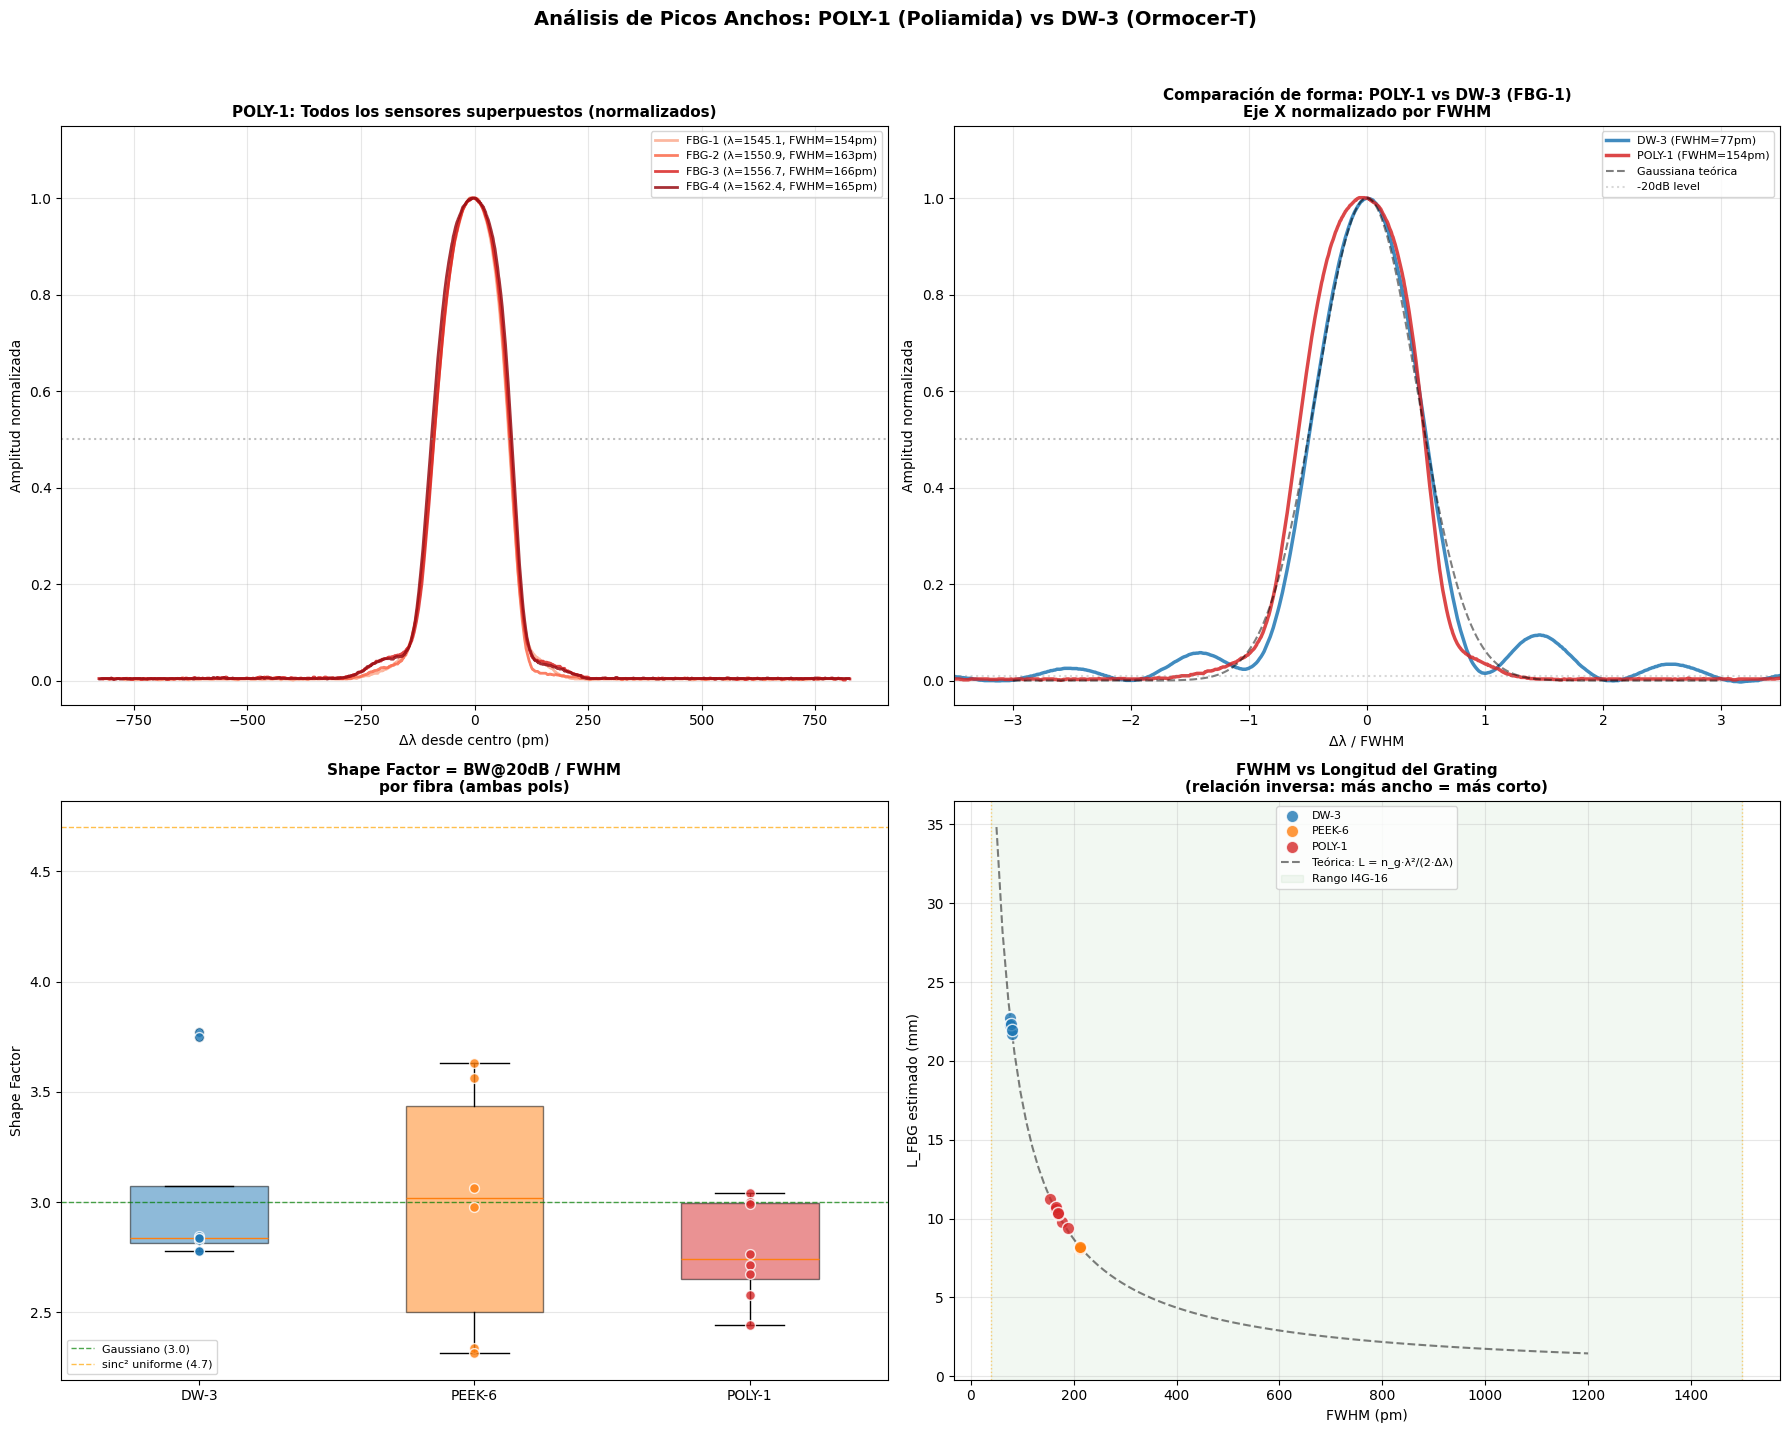

📊 DIAGNÓSTICO: ¿Por qué los picos de POLY-1 son más anchos?

  DW-3:
    FWHM medio: 78 ± 1 pm
    SF medio:   3.05 ± 0.41
    L_FBG medio: 22.23 ± 0.29 mm
  POLY-1:
    FWHM medio: 169 ± 9 pm
    SF medio:   2.78 ± 0.20
    L_FBG medio: 10.38 ± 0.54 mm

  🔎 SF(POLY-1) = 2.78 vs SF(DW-3) = 3.05
     → POLY-1 tiene perfil cercano a Gaussiano → probable grating CORTO
     → El ensanchamiento es por longitud reducida, NO por chirp

  💡 CAUSAS PROBABLES del ensanchamiento en POLY-1:
     1. Grating más corto (L estimado menor → FWHM mayor)
     2. El coating de poliamida puede inducir strain no uniforme
     3. A T_amb, posible compresión del coating sobre el grating
     4. El 5º sensor fuera de rango sugiere diseño con λ altas → posible
        tensión residual del coating que desplace los picos


In [20]:
if data_spectrum is not None and 'quality_results' in locals():
    # ══════════════════════════════════════════════════════════════════════
    # Análisis de picos anchos: POLY-1 vs DW-3
    # ══════════════════════════════════════════════════════════════════════

    fig = plt.figure(figsize=(18, 14))

    # ── Panel 1: Todos los sensores de POLY-1 superpuestos ────────────
    ax1 = fig.add_subplot(2, 2, 1)

    ch_poly = list(channel_names.values()).index('POLY-1')
    sig_poly_p = spectrum_wav[idx_espectro, 0, ch_poly, :]
    sig_poly_s = spectrum_wav[idx_espectro, 1, ch_poly, :]
    sig_poly = (sig_poly_p + sig_poly_s) / 2.0

    peaks_poly = fbg_analysis_results.get('POLY-1', {}).get('Pol P', [])
    valid_poly = [p for p in peaks_poly
                  if EDGE_MARGIN_PTS < p['peak_idx'] < (n_puntos - EDGE_MARGIN_PTS)]

    poly_colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(valid_poly)))

    for i, peak in enumerate(valid_poly):
        pidx = peak['peak_idx']
        fwhm = peak['fwhm']
        lam_b = idx_to_wavelength(pidx)
        zoom = int(fwhm * 5)
        x0 = max(0, pidx - zoom)
        x1 = min(n_puntos, pidx + zoom)

        x_pm = (np.arange(x0, x1) - pidx) * dlam_nm_per_pt * 1e3
        y_norm = sig_poly[x0:x1] / sig_poly[pidx]

        fwhm_pm = fwhm * dlam_nm_per_pt * 1e3
        ax1.plot(x_pm, y_norm, color=poly_colors[i], linewidth=2, alpha=0.85,
                 label=f'FBG-{i+1} (λ={lam_b:.1f}, FWHM={fwhm_pm:.0f}pm)')

    ax1.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
    ax1.set_title('POLY-1: Todos los sensores superpuestos (normalizados)',
                  fontsize=11, fontweight='bold')
    ax1.set_xlabel('Δλ desde centro (pm)', fontsize=10)
    ax1.set_ylabel('Amplitud normalizada', fontsize=10)
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(-0.05, 1.15)

    # ── Panel 2: POLY-1 FBG-1 vs DW-3 FBG-1 (forma del pico) ────────
    ax2 = fig.add_subplot(2, 2, 2)

    ch_dw = list(channel_names.values()).index('DW-3')
    sig_dw = (spectrum_wav[idx_espectro, 0, ch_dw, :] +
              spectrum_wav[idx_espectro, 1, ch_dw, :]) / 2.0

    peaks_dw = fbg_analysis_results.get('DW-3', {}).get('Pol P', [])
    valid_dw = [p for p in peaks_dw
                if EDGE_MARGIN_PTS < p['peak_idx'] < (n_puntos - EDGE_MARGIN_PTS)]

    for fiber_name, signal, valid_peaks, color in [
        ('DW-3', sig_dw, valid_dw, 'tab:blue'),
        ('POLY-1', sig_poly, valid_poly, 'tab:red')
    ]:
        if len(valid_peaks) == 0:
            continue
        peak = valid_peaks[0]
        pidx = peak['peak_idx']
        fwhm = peak['fwhm']
        fwhm_pm = fwhm * dlam_nm_per_pt * 1e3
        zoom = int(fwhm * 5)
        x0 = max(0, pidx - zoom)
        x1 = min(n_puntos, pidx + zoom)

        # Eje normalizado por FWHM (x en unidades de FWHM)
        x_fwhm = (np.arange(x0, x1) - pidx) / fwhm
        y_norm = signal[x0:x1] / signal[pidx]

        ax2.plot(x_fwhm, y_norm, color=color, linewidth=2.5, alpha=0.85,
                 label=f'{fiber_name} (FWHM={fwhm_pm:.0f}pm)')

    # Referencia Gaussiana teórica
    x_gauss = np.linspace(-3, 3, 500)
    y_gauss = np.exp(-4 * np.log(2) * x_gauss**2)
    ax2.plot(x_gauss, y_gauss, 'k--', linewidth=1.5, alpha=0.5, label='Gaussiana teórica')

    ax2.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
    ax2.axhline(0.01, color='gray', linestyle=':', alpha=0.3, label='-20dB level')
    ax2.set_title('Comparación de forma: POLY-1 vs DW-3 (FBG-1)\nEje X normalizado por FWHM',
                  fontsize=11, fontweight='bold')
    ax2.set_xlabel('Δλ / FWHM', fontsize=10)
    ax2.set_ylabel('Amplitud normalizada', fontsize=10)
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(-0.05, 1.15)
    ax2.set_xlim(-3.5, 3.5)

    # ── Panel 3: Shape Factor comparison ──────────────────────────────
    ax3 = fig.add_subplot(2, 2, 3)

    sf_data = {}
    for fiber_name in ['DW-3', 'PEEK-6', 'POLY-1']:
        if fiber_name not in quality_results:
            continue
        sfs = []
        for key, r in quality_results[fiber_name].items():
            sf_val = r.get('shape_factor', np.nan)
            if not np.isnan(sf_val):
                sfs.append(sf_val)
        if sfs:
            sf_data[fiber_name] = sfs

    if sf_data:
        positions = []
        box_data = []
        box_colors = []
        for i, (fn, sfs) in enumerate(sf_data.items()):
            positions.append(i)
            box_data.append(sfs)
            box_colors.append(colors_fiber[fn])

        bp = ax3.boxplot(box_data, positions=positions, widths=0.5, patch_artist=True)
        for patch, color in zip(bp['boxes'], box_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.5)

        # Scatter individual points
        for i, (fn, sfs) in enumerate(sf_data.items()):
            ax3.scatter([i] * len(sfs), sfs, color=colors_fiber[fn],
                       s=50, zorder=5, alpha=0.8, edgecolor='white')

        # Reference lines
        ax3.axhline(3.0, color='green', linestyle='--', linewidth=1, alpha=0.7,
                    label='Gaussiano (3.0)')
        ax3.axhline(4.7, color='orange', linestyle='--', linewidth=1, alpha=0.7,
                    label='sinc² uniforme (4.7)')

        ax3.set_xticks(positions)
        ax3.set_xticklabels(list(sf_data.keys()), fontsize=10)
        ax3.set_title('Shape Factor = BW@20dB / FWHM\npor fibra (ambas pols)',
                      fontsize=11, fontweight='bold')
        ax3.set_ylabel('Shape Factor', fontsize=10)
        ax3.legend(fontsize=8)
        ax3.grid(True, axis='y', alpha=0.3)

    # ── Panel 4: FWHM vs Grating Length ───────────────────────────────
    ax4 = fig.add_subplot(2, 2, 4)

    for fiber_name in ['DW-3', 'PEEK-6', 'POLY-1']:
        if fiber_name not in quality_results:
            continue
        fwhms = []
        lengths = []
        for key, r in quality_results[fiber_name].items():
            fw = r.get('bw_3db_pm', np.nan)
            ll = r.get('fbg_length_mm', np.nan)
            if not np.isnan(fw) and not np.isnan(ll):
                fwhms.append(fw)
                lengths.append(ll)
        if fwhms:
            ax4.scatter(fwhms, lengths, color=colors_fiber[fiber_name],
                       s=80, alpha=0.8, edgecolor='white', label=fiber_name, zorder=5)

    # Theoretical curve: L = (n_eff * lambda^2) / (2 * FWHM_nm * 1e6)
    fwhm_theory = np.linspace(50, 1200, 100)
    L_theory = (1.45 * 1550**2) / (2 * fwhm_theory * 1e-3 * 1e6)
    ax4.plot(fwhm_theory, L_theory, 'k--', linewidth=1.5, alpha=0.5,
             label='Teórica: L = n_g·λ²/(2·Δλ)')

    # I4G-16 FWHM range
    ax4.axvline(40, color='orange', linestyle=':', linewidth=1, alpha=0.5)
    ax4.axvline(1500, color='orange', linestyle=':', linewidth=1, alpha=0.5)
    ax4.axvspan(40, 1500, alpha=0.05, color='green', label='Rango I4G-16')

    ax4.set_title('FWHM vs Longitud del Grating\n(relación inversa: más ancho = más corto)',
                  fontsize=11, fontweight='bold')
    ax4.set_xlabel('FWHM (pm)', fontsize=10)
    ax4.set_ylabel('L_FBG estimado (mm)', fontsize=10)
    ax4.legend(fontsize=8)
    ax4.grid(True, alpha=0.3)

    plt.suptitle('Análisis de Picos Anchos: POLY-1 (Poliamida) vs DW-3 (Ormocer-T)',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # ── Diagnóstico textual ───────────────────────────────────────────
    print("📊 DIAGNÓSTICO: ¿Por qué los picos de POLY-1 son más anchos?")
    print()

    # Comparar métricas
    for fiber_name in ['DW-3', 'POLY-1']:
        if fiber_name not in quality_results:
            continue
        fwhms = [r['bw_3db_pm'] for r in quality_results[fiber_name].values()
                 if not np.isnan(r.get('bw_3db_pm', np.nan))]
        sfs = [r.get('shape_factor', np.nan) for r in quality_results[fiber_name].values()]
        sfs = [v for v in sfs if not np.isnan(v)]
        ls = [r['fbg_length_mm'] for r in quality_results[fiber_name].values()
              if not np.isnan(r['fbg_length_mm'])]

        print(f"  {fiber_name}:")
        print(f"    FWHM medio: {np.mean(fwhms):.0f} ± {np.std(fwhms):.0f} pm")
        print(f"    SF medio:   {np.mean(sfs):.2f} ± {np.std(sfs):.2f}" if sfs else "    SF: N/A")
        print(f"    L_FBG medio: {np.mean(ls):.2f} ± {np.std(ls):.2f} mm")

    print()
    if sf_data.get('POLY-1') and sf_data.get('DW-3'):
        sf_poly = np.mean(sf_data['POLY-1'])
        sf_dw = np.mean(sf_data['DW-3'])
        print(f"  🔎 SF(POLY-1) = {sf_poly:.2f} vs SF(DW-3) = {sf_dw:.2f}")
        if sf_poly < 3.5:
            print("     → POLY-1 tiene perfil cercano a Gaussiano → probable grating CORTO")
            print("     → El ensanchamiento es por longitud reducida, NO por chirp")
        elif sf_poly > 5.0:
            print("     → SF alto → indica CHIRP no intencionado")
            print("     → Posible gradiente de strain del coating de poliamida")
        else:
            print("     → SF intermedio → perfil entre Gaussiano y sinc²")
            print("     → Grating moderadamente largo, posible leve chirp del coating")

    print()
    print("  💡 CAUSAS PROBABLES del ensanchamiento en POLY-1:")
    print("     1. Grating más corto (L estimado menor → FWHM mayor)")
    print("     2. El coating de poliamida puede inducir strain no uniforme")
    print("     3. A T_amb, posible compresión del coating sobre el grating")
    print("     4. El 5º sensor fuera de rango sugiere diseño con λ altas → posible")
    print("        tensión residual del coating que desplace los picos")

## 9️⃣ Guardar Resultados

Exporta la tabla resumen a CSV para análisis posterior.

In [21]:
if data_spectrum is not None and 'df_summary' in locals():
    output_csv = "/afs/cern.ch/user/v/vgarciap/rtd-calibration-ana/FBG_Sensitivity_Analysis/FBG_quality_summary_20260304.csv"
    df_summary.to_csv(output_csv, index=False)
    print(f"✅ Tabla resumen guardada en: {output_csv}")
    print(f"   Columnas: {', '.join(df_summary.columns)}")
    print(f"   Filas: {len(df_summary)}")

    # También guardar cross-pol si existe
    if 'df_xpol' in locals():
        xp_csv = output_csv.replace('.csv', '_cross_pol.csv')
        df_xpol.to_csv(xp_csv, index=False)
        print(f"✅ Cross-polarización guardada en: {xp_csv}")

✅ Tabla resumen guardada en: /afs/cern.ch/user/v/vgarciap/rtd-calibration-ana/FBG_Sensitivity_Analysis/FBG_quality_summary_20260304.csv
   Columnas: Fibra, FBG, Pol, peak_idx, lambda_B_nm, spacing_nm, FWHM_pm, BW20_pm, SF, Amp_cts, SNR_dB, SLSR_dB, SLSR_ratio, d_SL_nm, SAR_pct, L_mm
   Filas: 22
✅ Cross-polarización guardada en: /afs/cern.ch/user/v/vgarciap/rtd-calibration-ana/FBG_Sensitivity_Analysis/FBG_quality_summary_20260304_cross_pol.csv
